# Sales Performance and Customer Profitability Analysis

## 1. Project Overview

This project analyses sales, customer, product, inventory and discount performance for a synthetic wholesale frame distribution business.

The goal is to simulate a realistic business analytics workflow where raw sales data is transformed into actionable insights for product management, customer prioritisation, inventory planning and commercial decision-making.

The project was designed as a portfolio-level data analysis case study using Python, pandas, NumPy and Matplotlib.

## 2. Load Data

In [4]:
import pandas as pd
import numpy as np

orders = pd.read_csv("data/sales_orders.csv")
customers = pd.read_csv("data/customers.csv")
products = pd.read_csv("data/products.csv")

## 3. Initial Data Inspection

This section provides a first overview of the input datasets, including sample rows, dataset dimensions, data types and missing values.

In [6]:
display(orders.head())

dataset_overview = pd.DataFrame({
    "dataset": ["orders", "customers", "products"],
    "rows": [orders.shape[0], customers.shape[0], products.shape[0]],
    "columns": [orders.shape[1], customers.shape[1], products.shape[1]]
})

display(dataset_overview)

,order_id,order_date,customer_id,product_id,sales_rep,channel,quantity,unit_price,discount_pct,unit_cost,payment_days,returned_qty,order_status
0,O1058,2025-12-08,C008,P001,Giorgos,Wholesale,14,14.99,0.03,10.80,15.0,0,Completed
1,O1272,2025-12-23,C046,P023,Eleni,Wholesale,13,16.26,0.05,10.30,30.0,0,Pending
2,O1453,2025-04-09,C042,P003,Giorgos,Direct,10,8.23,0.09,6.17,60.0,0,Completed
3,O1160,2025-07-14,C085,P021,Maria,Direct,12,19.64,0.02,12.46,60.0,0,Completed
4,O1115,2025-06-04,C026,P004,Giorgos,Wholesale,14,9.14,0.08,6.26,45.0,0,Completed


,dataset,rows,columns
0,orders,1510,13
1,customers,90,7
2,products,36,9


In [7]:
display(customers.head())
display(products.head())

,customer_id,customer_name,city,region,customer_type,signup_date,credit_segment
0,C001,Gallery_001,Athens,Attica,Gallery,2023-04-13,low_risk
1,C002,Frame_002,Veria,Central Macedonia,Frame shop,2024-03-11,medium_risk
2,C003,Home_003,Patra,Western Greece,Home decor store,2025-05-10,low_risk
3,C004,Frame_004,Piraeus,Attica,Frame shop,2023-09-28,medium_risk
4,C005,Gallery_005,Patra,Western Greece,Gallery,2023-04-17,medium_risk


,product_id,product_name,category,style,supplier_country,list_price,standard_cost,current_stock,reorder_point
0,P001,Wood frame V1,Classic,Modern,Turkey,14.99,10.51,239,48
1,P002,Wood frame V2,Classic,Vintage,Spain,8.02,5.44,193,59
2,P003,Wood frame V3,Classic,Vintage,China,8.23,5.90,127,35
3,P004,Metal frame V1,Classic,Modern,Poland,9.14,6.08,44,76
4,P005,Metal frame V2,Classic,Vintage,Spain,9.46,4.69,190,58


In [8]:
display(orders.dtypes)

order_id         object
order_date       object
customer_id      object
product_id       object
sales_rep        object
channel          object
quantity          int64
unit_price      float64
discount_pct    float64
unit_cost       float64
payment_days    float64
returned_qty      int64
order_status     object
dtype: object

In [9]:
missing_summary = pd.concat([
    pd.DataFrame({
        "dataset": "orders",
        "column": orders.columns,
        "missing_values": orders.isna().sum().values,
        "missing_pct": (orders.isna().mean() * 100).round(2).values
    }),
    pd.DataFrame({
        "dataset": "customers",
        "column": customers.columns,
        "missing_values": customers.isna().sum().values,
        "missing_pct": (customers.isna().mean() * 100).round(2).values
    }),
    pd.DataFrame({
        "dataset": "products",
        "column": products.columns,
        "missing_values": products.isna().sum().values,
        "missing_pct": (products.isna().mean() * 100).round(2).values
    })
], ignore_index=True)

missing_summary[missing_summary["missing_values"] > 0]

,dataset,column,missing_values,missing_pct
8,orders,discount_pct,20,1.32
10,orders,payment_days,8,0.53


In [10]:
missing_summary.groupby("dataset")["missing_values"].sum().reset_index()

,dataset,missing_values
0,customers,0
1,orders,28
2,products,0


In [11]:
duplicated_summary = pd.DataFrame({
    "dataset": ["orders", "products", "customers"],
    "duplicate_rows": [orders.duplicated().sum(), products.duplicated().sum(), customers.duplicated().sum()]})

display(duplicated_summary)

,dataset,duplicate_rows
0,orders,10
1,products,0
2,customers,0


In [12]:
dimension_key_summary = pd.DataFrame({
    "dataset": ["orders","customers", "products"],
    "key_column": ["order_id","customer_id", "product_id"],
    "duplicate_keys": [
        orders["order_id"].duplicated().sum(),
        customers["customer_id"].duplicated().sum(),
        products["product_id"].duplicated().sum()
    ]
})

display(dimension_key_summary)

,dataset,key_column,duplicate_keys
0,orders,order_id,927
1,customers,customer_id,0
2,products,product_id,0


The orders dataset contains repeated order IDs because each row represents an order line rather than a unique order. Therefore, repeated order IDs are expected, while full duplicate rows are treated as data quality issues.

In [14]:
order_structure_summary = pd.DataFrame({
    "metric": [
        "total_order_rows",
        "unique_order_ids",
        "repeated_order_id_rows"
    ],
    "value": [
        len(orders),
        orders["order_id"].nunique(),
        orders["order_id"].duplicated().sum()
    ]
})

display(order_structure_summary)

,metric,value
0,total_order_rows,1510
1,unique_order_ids,583
2,repeated_order_id_rows,927


## 4. Data Cleaning

This section creates clean copies of the original datasets, removes full duplicate rows, standardises text fields and converts date columns into proper datetime format.

### 4.1 Create clean copies and remove duplicate rows

In [17]:
orders_clean = orders.copy()
products_clean = products.copy()
customers_clean = customers.copy()

orders_clean = orders_clean.drop_duplicates().reset_index(drop=True)
customers_clean = customers_clean.drop_duplicates().reset_index(drop=True)
products_clean = products_clean.drop_duplicates().reset_index(drop=True)

### 4.2 Standardise IDs and text columns

In [19]:
orders_clean["order_id"] = orders_clean["order_id"].str.strip().str.upper()
orders_clean["customer_id"] = orders_clean["customer_id"].str.strip().str.upper()
orders_clean["product_id"] = orders_clean["product_id"].str.strip().str.upper()

products_clean["product_id"] = products_clean["product_id"].str.strip().str.upper()
customers_clean["customer_id"] = customers_clean["customer_id"].str.strip().str.upper()

orders_clean["sales_rep"] = orders_clean["sales_rep"].str.strip().str.title()
orders_clean["channel"] = orders_clean["channel"].str.strip().str.title()
orders_clean["order_status"] = orders_clean["order_status"].str.strip().str.title()

customers_clean["customer_name"] = customers_clean["customer_name"].str.strip()
customers_clean["city"] = customers_clean["city"].str.strip().str.title()
customers_clean["region"] = customers_clean["region"].str.strip().str.title()
customers_clean["customer_type"] = customers_clean["customer_type"].str.strip().str.title()
customers_clean["credit_segment"] = customers_clean["credit_segment"].str.strip().str.lower()

products_clean["product_name"] = products_clean["product_name"].str.strip().str.title()
products_clean["category"] = products_clean["category"].str.strip().str.title()
products_clean["style"] = products_clean["style"].str.strip().str.title()
products_clean["supplier_country"] = products_clean["supplier_country"].str.strip().str.title()

### 4.3 Convert date columns

In [21]:
orders_clean["order_date"] = pd.to_datetime(orders_clean["order_date"])
customers_clean["signup_date"] = pd.to_datetime(customers_clean["signup_date"])

### 4.4 Handle missing values

In [23]:
orders_clean["discount_pct"] = orders_clean["discount_pct"].fillna(0)
orders_clean["payment_days"] = orders_clean["payment_days"].fillna(orders_clean["payment_days"].median())


### 4.5 Convert numeric columns

In [25]:
orders_clean["quantity"] = orders_clean["quantity"].astype(int)
orders_clean["payment_days"] = orders_clean["payment_days"].astype(int)
orders_clean["returned_qty"] = orders_clean["returned_qty"].astype(int)
products_clean["current_stock"] = products_clean["current_stock"].astype(int)
products_clean["reorder_point"] = products_clean["reorder_point"].astype(int)

### 4.5 Validate cleaned datasets

In [27]:
cleaning_summary = pd.DataFrame({
    "dataset": ["orders_clean", "customers_clean", "products_clean"],
    "rows": [
        orders_clean.shape[0],
        customers_clean.shape[0],
        products_clean.shape[0]
    ],
    "remaining_missing_values": [
        orders_clean.isna().sum().sum(),
        customers_clean.isna().sum().sum(),
        products_clean.isna().sum().sum()
    ],
    "remaining_duplicate_rows": [
        orders_clean.duplicated().sum(),
        customers_clean.duplicated().sum(),
        products_clean.duplicated().sum()
    ]
})

display(cleaning_summary)
display(orders_clean.dtypes)

,dataset,rows,remaining_missing_values,remaining_duplicate_rows
0,orders_clean,1500,0,0
1,customers_clean,90,0,0
2,products_clean,36,0,0


order_id                object
order_date      datetime64[ns]
customer_id             object
product_id              object
sales_rep               object
channel                 object
quantity                 int32
unit_price             float64
discount_pct           float64
unit_cost              float64
payment_days             int32
returned_qty             int32
order_status            object
dtype: object

### 4.6 Validate cleaned data

After cleaning, data types and basic logical constraints were checked to confirm that the cleaned datasets are suitable for analysis.

In [29]:
logical_checks = pd.DataFrame({
    "check": [
        "returned_qty > quantity",
        "negative quantity",
        "unit_price <= 0",
        "unit_cost <= 0"
    ],
    "issues_found": [
        (orders_clean["returned_qty"] > orders_clean["quantity"]).sum(),
        (orders_clean["quantity"] < 0).sum(),
        (orders_clean["unit_price"] <= 0).sum(),
        (orders_clean["unit_cost"] <= 0).sum()
    ]
})

display(logical_checks)

,check,issues_found
0,returned_qty > quantity,0
1,negative quantity,0
2,unit_price <= 0,0
3,unit_cost <= 0,0


## 5. Data Merging and Feature Engineering

This section combines the cleaned orders, customers and products datasets into a single analysis dataset. Customer information is added using `customer_id`, while product information is added using `product_id`.

### 5.1 Merge cleaned datasets

In [32]:
#merge orders with customers
sales_df = orders_clean.merge(
    customers_clean,
    on="customer_id",
    how="left"
)

sales_df = sales_df.merge(
    products_clean,
    on="product_id",
    how="left"
)

In [33]:
display(sales_df.head())
merge_validation = pd.DataFrame({
    "check": [
        "orders rows before merge",
        "sales_df rows after merge",
        "missing customer matches",
        "missing product matches"
    ],
    "value": [
        orders_clean.shape[0],
        sales_df.shape[0],
        sales_df["customer_name"].isna().sum(),
        sales_df["product_name"].isna().sum()
    ]
})

display(merge_validation)

,order_id,order_date,customer_id,product_id,sales_rep,channel,quantity,unit_price,discount_pct,unit_cost,...,signup_date,credit_segment,product_name,category,style,supplier_country,list_price,standard_cost,current_stock,reorder_point
0,O1058,2025-12-08,C008,P001,Giorgos,Wholesale,14,14.99,0.03,10.80,...,2023-01-21,low_risk,Wood Frame V1,Classic,Modern,Turkey,14.99,10.51,239,48
1,O1272,2025-12-23,C046,P023,Eleni,Wholesale,13,16.26,0.05,10.30,...,2023-07-09,low_risk,Black Frame V2,Modern,Rustic,China,16.26,10.58,72,48
2,O1453,2025-04-09,C042,P003,Giorgos,Direct,10,8.23,0.09,6.17,...,2024-11-12,high_risk,Wood Frame V3,Classic,Vintage,China,8.23,5.90,127,35
3,O1160,2025-07-14,C085,P021,Maria,Direct,12,19.64,0.02,12.46,...,2024-01-25,high_risk,Minimal Frame V3,Modern,Rustic,Spain,19.64,12.45,114,83
4,O1115,2025-06-04,C026,P004,Giorgos,Wholesale,14,9.14,0.08,6.26,...,2024-02-18,low_risk,Metal Frame V1,Classic,Modern,Poland,9.14,6.08,44,76


,check,value
0,orders rows before merge,1500
1,sales_df rows after merge,1500
2,missing customer matches,0
3,missing product matches,0


### 5.2 Create revenue and profit metrics

This step creates the main financial metrics used throughout the analysis, including gross revenue, discount amount, returned revenue, net revenue, cost amount, gross profit and margin percentage.

In [35]:
sales_df["net_quantity"] = sales_df["quantity"] - sales_df["returned_qty"]

sales_df["gross_revenue"] = (
    sales_df["quantity"] * sales_df["unit_price"]
)

sales_df["discount_amount"] = (
    sales_df["gross_revenue"] * sales_df["discount_pct"]
)

sales_df["returned_revenue"] = (
    sales_df["returned_qty"]
    * sales_df["unit_price"]
    * (1 - sales_df["discount_pct"])
)

sales_df["net_revenue"] = (
    sales_df["gross_revenue"]
    - sales_df["discount_amount"]
    - sales_df["returned_revenue"]
)

sales_df["cost_amount"] = (
    sales_df["net_quantity"] * sales_df["unit_cost"]
)

sales_df["gross_profit"] = (
    sales_df["net_revenue"] - sales_df["cost_amount"]
)
#safe margin calculation
sales_df["margin_pct"] = np.where(
    sales_df["net_revenue"] != 0,
    sales_df["gross_profit"] / sales_df["net_revenue"],
    0
)


### 5.3 Create date features

In [37]:
# date features
sales_df["order_month"] = sales_df["order_date"].dt.to_period("M").astype(str)
sales_df["order_quarter"] = sales_df["order_date"].dt.to_period("Q").astype(str)

### 5.4 Validate financial metrics

In [39]:
financial_validation = pd.DataFrame({
    "check": [
        "negative net quantity",
        "negative net revenue",
        "margin percentage greater than 100%",
        "margin percentage less than -100%"
    ],
    "issues_found": [
        (sales_df["net_quantity"] < 0).sum(),
        (sales_df["net_revenue"] < 0).sum(),
        (sales_df["margin_pct"] > 1).sum(),
        (sales_df["margin_pct"] < -1).sum()
    ]
})

display(financial_validation)

display(
    sales_df[
    [
        "quantity", "returned_qty", "net_quantity",
        "gross_revenue", "discount_amount", "net_revenue",
        "cost_amount", "gross_profit", "margin_pct",
        "order_month", "order_quarter"
    ]
    ].head()
)

,check,issues_found
0,negative net quantity,0
1,negative net revenue,0
2,margin percentage greater than 100%,0
3,margin percentage less than -100%,0


,quantity,returned_qty,net_quantity,gross_revenue,discount_amount,net_revenue,cost_amount,gross_profit,margin_pct,order_month,order_quarter
0,14,0,14,209.86,6.2958,203.5642,151.20,52.3642,0.257237,2025-12,2025Q4
1,13,0,13,211.38,10.5690,200.8110,133.90,66.9110,0.333204,2025-12,2025Q4
2,10,0,10,82.30,7.4070,74.8930,61.70,13.1930,0.176158,2025-04,2025Q2
3,12,0,12,235.68,4.7136,230.9664,149.52,81.4464,0.352633,2025-07,2025Q3
4,14,0,14,127.96,10.2368,117.7232,87.64,30.0832,0.255542,2025-06,2025Q2


### 5.5 Create final analysis dataset

In [41]:
analysis_df = sales_df[sales_df["order_status"] == "Completed"].copy()
analysis_dataset_summary = pd.DataFrame({
    "metric": [
        "total rows in sales_df",
        "completed order rows in analysis_df",
        "unique completed orders"
    ],
    "value": [
        sales_df.shape[0],
        analysis_df.shape[0],
        analysis_df["order_id"].nunique()
    ]
})

display(analysis_dataset_summary)

,metric,value
0,total rows in sales_df,1500
1,completed order rows in analysis_df,1360
2,unique completed orders,569


### 5.6 KPI Overview

In [43]:
total_net_revenue = analysis_df["net_revenue"].sum()
total_gross_profit = analysis_df["gross_profit"].sum()
overall_margin = total_gross_profit / total_net_revenue
total_orders = analysis_df["order_id"].nunique()
total_customers = analysis_df["customer_id"].nunique()
total_products = analysis_df["product_id"].nunique()
overall_return_rate = analysis_df["returned_qty"].sum() / analysis_df["quantity"].sum()

kpi_summary = pd.DataFrame({
    "metric": [
        "Total net revenue",
        "Total gross profit",
        "Overall margin",
        "Total completed orders",
        "Total customers",
        "Total products",
        "Overall return rate"
    ],
    "value": [
        round(total_net_revenue, 2),
        round(total_gross_profit, 2),
        round(overall_margin * 100, 2),
        total_orders,
        total_customers,
        total_products,
        round(overall_return_rate * 100, 2)
    ],
    "unit": [
        "€",
        "€",
        "%",
        "orders",
        "customers",
        "products",
        "%"
    ]
})

display(kpi_summary)

,metric,value,unit
0,Total net revenue,210752.67,€
1,Total gross profit,77276.63,€
2,Overall margin,36.67,%
3,Total completed orders,569.00,orders
4,Total customers,90.00,customers
5,Total products,36.00,products
6,Overall return rate,1.00,%


## 6. Product Analysis

This section analyses product performance using revenue, gross profit, margin, returns and inventory status.

### 6.1 Create product summary

In [46]:
sales_df_all_orders = sales_df.copy()

product_summary = analysis_df.groupby(
    ["product_id", "product_name", "category", "style", "supplier_country", "current_stock", "reorder_point"], 
    as_index=False
).agg( 
    unique_orders=("order_id", "nunique"),
    total_orders=("order_id", "count"),
    total_qty=("quantity", "sum"),
    total_returned_qty=("returned_qty", "sum"),
    total_net_qty=("net_quantity", "sum"),
    gross_revenue=("gross_revenue", "sum"),
    discount_amount=("discount_amount", "sum"),
    net_revenue=("net_revenue", "sum"),
    cost_amount=("cost_amount", "sum"),
    gross_profit=("gross_profit", "sum")
)

product_summary["return_rate"] = np.where(
    product_summary["total_qty"] != 0,
    product_summary["total_returned_qty"] / product_summary["total_qty"],
    0
)

product_summary["margin_pct"] = np.where(
    product_summary["net_revenue"] != 0,
    product_summary["gross_profit"] / product_summary["net_revenue"],
    0
)

product_summary["discount_pct_effective"] = np.where(
    product_summary["gross_revenue"] != 0,
    product_summary["discount_amount"] / product_summary["gross_revenue"],
    0
)

product_summary["stock_gap"] = product_summary["current_stock"] - product_summary["reorder_point"]

display(product_summary[
    [
        "product_id", "product_name", "category", "total_net_qty",
        "net_revenue", "gross_profit", "margin_pct",
        "current_stock", "reorder_point", "stock_gap"
    ]
].head())

,product_id,product_name,category,total_net_qty,net_revenue,gross_profit,margin_pct,current_stock,reorder_point,stock_gap
0,P001,Wood Frame V1,Classic,500,7244.8169,1915.8369,0.264442,239,48,191
1,P002,Wood Frame V2,Classic,432,3304.4806,925.3606,0.280032,193,59,134
2,P003,Wood Frame V3,Classic,563,4423.3781,1072.7481,0.242518,127,35,92
3,P004,Metal Frame V1,Classic,537,4701.2504,1414.9904,0.300982,44,76,-32
4,P005,Metal Frame V2,Classic,455,4122.9518,1969.4018,0.477668,190,58,132


### 6.2 Top product performance

In [48]:
product_summary.sort_values("net_revenue", ascending=False)[
    ["product_name", "category", "total_net_qty", "net_revenue", "gross_profit", "margin_pct"]
].head(10)

,product_name,category,total_net_qty,net_revenue,gross_profit,margin_pct
12,Silver Frame V1,Premium,365,8751.9610,3773.5210,0.431163
26,White Frame V3,Modern,454,8430.0278,2215.6778,0.262832
27,Mirror Frame V1,Decor,432,8240.2320,3867.1920,0.469306
21,Black Frame V1,Modern,565,8123.4382,2605.3882,0.320725
34,Art Frame V2,Decor,377,7753.6771,3050.9771,0.393488
35,Art Frame V3,Decor,404,7515.2253,2961.3153,0.394042
33,Art Frame V1,Decor,358,7434.7464,3471.1164,0.466878
23,Black Frame V3,Modern,457,7367.4664,2560.2164,0.347503
20,Minimal Frame V3,Modern,390,7355.7692,2412.4192,0.327963
0,Wood Frame V1,Classic,500,7244.8169,1915.8369,0.264442


In [49]:
product_summary.sort_values("gross_profit", ascending=False)[
    ["product_name", "category", "total_net_qty", "net_revenue", "gross_profit", "margin_pct"]
].head(10)

,product_name,category,total_net_qty,net_revenue,gross_profit,margin_pct
27,Mirror Frame V1,Decor,432,8240.2320,3867.1920,0.469306
12,Silver Frame V1,Premium,365,8751.9610,3773.5210,0.431163
33,Art Frame V1,Decor,358,7434.7464,3471.1164,0.466878
14,Silver Frame V3,Premium,332,6885.4974,3242.7574,0.470955
18,Minimal Frame V1,Modern,483,6814.5444,3052.2444,0.447901
34,Art Frame V2,Decor,377,7753.6771,3050.9771,0.393488
35,Art Frame V3,Decor,404,7515.2253,2961.3153,0.394042
16,Oak Frame V2,Premium,340,5587.4160,2751.7660,0.492493
21,Black Frame V1,Modern,565,8123.4382,2605.3882,0.320725
13,Silver Frame V2,Premium,306,5289.0600,2569.1800,0.485754


In [50]:
product_summary.sort_values("return_rate", ascending=False)[
    ["product_name", "category", "total_net_qty", "net_revenue", "gross_profit", "margin_pct", "return_rate"]
].head(10)

,product_name,category,total_net_qty,net_revenue,gross_profit,margin_pct,return_rate
11,Gold Frame V3,Premium,275,5121.7685,1317.8585,0.257305,0.035088
4,Metal Frame V2,Classic,455,4122.9518,1969.4018,0.477668,0.033970
9,Gold Frame V1,Premium,263,6296.6865,1725.1365,0.273975,0.025926
25,White Frame V2,Modern,365,5592.3460,2046.4860,0.365944,0.021448
30,Poster Frame V1,Decor,315,4634.2087,1971.9187,0.425514,0.018692
28,Mirror Frame V2,Decor,341,5735.9740,1463.3440,0.255117,0.017291
23,Black Frame V3,Modern,457,7367.4664,2560.2164,0.347503,0.017204
31,Poster Frame V2,Decor,328,4186.5740,1672.7340,0.399547,0.015015
35,Art Frame V3,Decor,404,7515.2253,2961.3153,0.394042,0.014634
24,White Frame V1,Modern,440,6699.9966,1801.5966,0.268895,0.013453


In [51]:
product_summary.sort_values("net_revenue",ascending=False)[["net_revenue","gross_profit","margin_pct","discount_pct_effective","return_rate"]]

product_summary["revenue_rank"] = product_summary["net_revenue"].rank(ascending=False, method="min").astype(int)
product_summary["profit_rank"] = product_summary["gross_profit"].rank(ascending=False, method="min").astype(int)
product_summary["rank_gap_profit_vs_revenue"] = product_summary["profit_rank"] - product_summary["revenue_rank"]
top_revenue_product_review = (
    product_summary
    .sort_values("net_revenue", ascending=False)
    [[
        "product_name",
        "category",
        "total_net_qty",
        "net_revenue",
        "gross_profit",
        "margin_pct",
        "revenue_rank",
        "profit_rank",
        "rank_gap_profit_vs_revenue"
    ]]
    .head(10)
)

top_revenue_product_review


,product_name,category,total_net_qty,net_revenue,gross_profit,margin_pct,revenue_rank,profit_rank,rank_gap_profit_vs_revenue
12,Silver Frame V1,Premium,365,8751.9610,3773.5210,0.431163,1,2,1
26,White Frame V3,Modern,454,8430.0278,2215.6778,0.262832,2,15,13
27,Mirror Frame V1,Decor,432,8240.2320,3867.1920,0.469306,3,1,-2
21,Black Frame V1,Modern,565,8123.4382,2605.3882,0.320725,4,9,5
34,Art Frame V2,Decor,377,7753.6771,3050.9771,0.393488,5,6,1
35,Art Frame V3,Decor,404,7515.2253,2961.3153,0.394042,6,7,1
33,Art Frame V1,Decor,358,7434.7464,3471.1164,0.466878,7,3,-4
23,Black Frame V3,Modern,457,7367.4664,2560.2164,0.347503,8,11,3
20,Minimal Frame V3,Modern,390,7355.7692,2412.4192,0.327963,9,13,4
0,Wood Frame V1,Classic,500,7244.8169,1915.8369,0.264442,10,22,12


### 6.3 Inventory status by product

In [53]:
conditions = [ 
    product_summary["current_stock"] <= product_summary["reorder_point"],
    product_summary["current_stock"] <= product_summary["reorder_point"]*1.2
]

choices = [
    "reorder_now",
    "watchlist"
]

product_summary["inventory_status"] = np.select(
    conditions,
    choices,
    default="healthy"
)

inventory_status_summary = (
    product_summary["inventory_status"]
    .value_counts()
    .reset_index()
)

inventory_status_summary.columns = ["inventory_status", "product_count"]

display(inventory_status_summary)

,inventory_status,product_count
0,healthy,28
1,reorder_now,7
2,watchlist,1


In [54]:
product_summary[
    (product_summary["inventory_status"] == "watchlist") | 
    (product_summary["inventory_status"] == "reorder_now")
].sort_values(["inventory_status", "stock_gap"])[
    ["product_name", "category", "current_stock", "reorder_point", "stock_gap", "inventory_status"]].head(10)

,product_name,category,current_stock,reorder_point,stock_gap,inventory_status
33,Art Frame V1,Decor,47,87,-40,reorder_now
3,Metal Frame V1,Classic,44,76,-32,reorder_now
19,Minimal Frame V2,Modern,48,75,-27,reorder_now
25,White Frame V2,Modern,43,69,-26,reorder_now
17,Oak Frame V3,Premium,50,62,-12,reorder_now
35,Art Frame V3,Decor,58,62,-4,reorder_now
24,White Frame V1,Modern,66,68,-2,reorder_now
8,Photo Frame V3,Classic,101,87,14,watchlist


### 6.4 Category Summary

This section compares product categories using quantity sold, net revenue, gross profit, margin, return rate and average discount.

In [56]:
category_summary = analysis_df.groupby("category", as_index=False).agg(
    total_qty=("quantity", "sum"),
    total_returned_qty=("returned_qty", "sum"),
    net_revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_discount_pct=("discount_pct", "mean")
)

category_summary["returned_rate"] = np.where(
    category_summary["total_qty"] !=0,
    category_summary["total_returned_qty"] / category_summary["total_qty"],
    0
)

category_summary["margin_pct"] = np.where(
    category_summary["net_revenue"] != 0,
    category_summary["gross_profit"] / category_summary["net_revenue"],
    0
)
display(category_summary)

,category,total_qty,total_returned_qty,net_revenue,gross_profit,avg_discount_pct,returned_rate,margin_pct
0,Classic,4299,36,42247.7515,14426.2915,0.033798,0.008374,0.341469
1,Decor,3294,33,56185.8361,22835.7861,0.036645,0.010018,0.406433
2,Modern,4058,46,61550.6991,20298.3391,0.037943,0.011336,0.329782
3,Premium,2708,28,50768.3810,19716.2110,0.036211,0.010340,0.388356


In [57]:
category_summary_ranked = category_summary.copy()

category_summary_ranked["revenue_rank"] = category_summary_ranked["net_revenue"].rank(
    ascending=False, method="dense"
).astype(int)

category_summary_ranked["profit_rank"] = category_summary_ranked["gross_profit"].rank(
    ascending=False, method="dense"
).astype(int)

category_summary_ranked["margin_rank"] = category_summary_ranked["margin_pct"].rank(
    ascending=False, method="dense"
).astype(int)

category_summary_ranked = category_summary_ranked.sort_values("net_revenue", ascending=False)

display(category_summary_ranked)

,category,total_qty,total_returned_qty,net_revenue,gross_profit,avg_discount_pct,returned_rate,margin_pct,revenue_rank,profit_rank,margin_rank
2,Modern,4058,46,61550.6991,20298.3391,0.037943,0.011336,0.329782,1,2,4
1,Decor,3294,33,56185.8361,22835.7861,0.036645,0.010018,0.406433,2,1,1
3,Premium,2708,28,50768.3810,19716.2110,0.036211,0.010340,0.388356,3,3,2
0,Classic,4299,36,42247.7515,14426.2915,0.033798,0.008374,0.341469,4,4,3


### 6.5 Product and Category Visualizations

The following charts visualise the main product and category findings, including revenue, gross profit and inventory-related patterns.

In [59]:
import matplotlib.pyplot as plt
top_products = product_summary.sort_values("net_revenue",ascending=False).head(10)

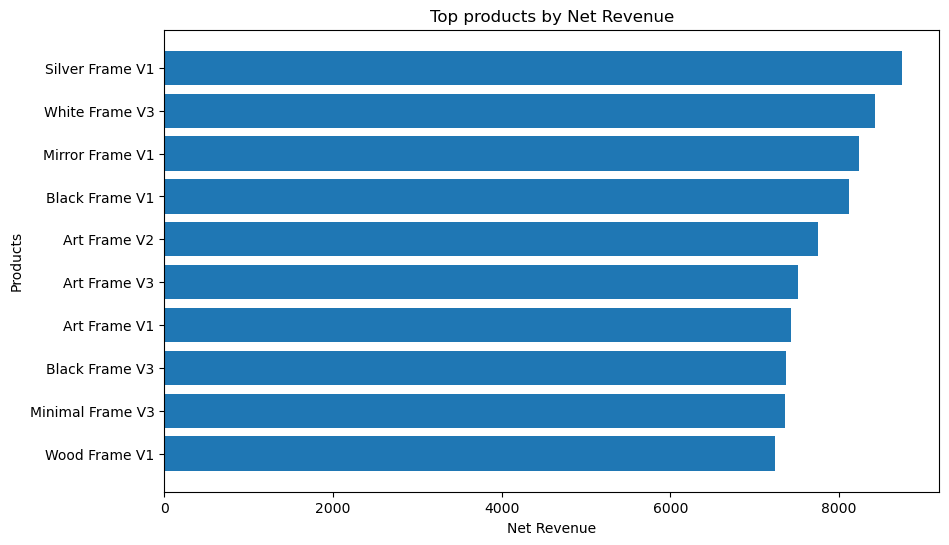

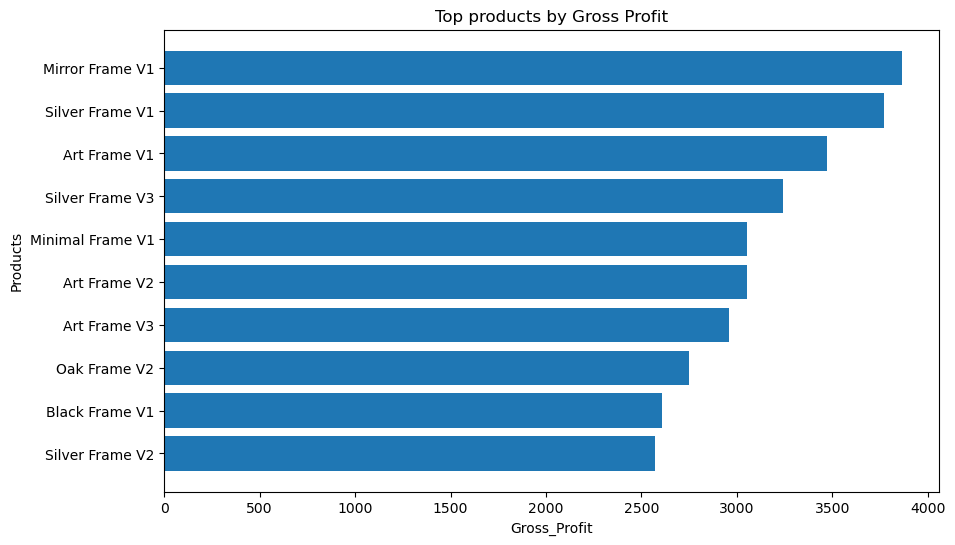

In [60]:
plt.figure(figsize=(10,6))
plt.barh(top_products["product_name"],top_products["net_revenue"])
plt.title("Top products by Net Revenue")
plt.ylabel("Products")
plt.xlabel("Net Revenue")
plt.gca().invert_yaxis()

top_profit_products = product_summary.sort_values("gross_profit",ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.barh(top_profit_products["product_name"],top_profit_products["gross_profit"])
plt.title("Top products by Gross Profit")
plt.ylabel("Products")
plt.xlabel("Gross_Profit")
plt.gca().invert_yaxis()

([0, 1, 2, 3],
 [Text(0, 0, 'Modern'),
  Text(1, 0, 'Decor'),
  Text(2, 0, 'Premium'),
  Text(3, 0, 'Classic')])

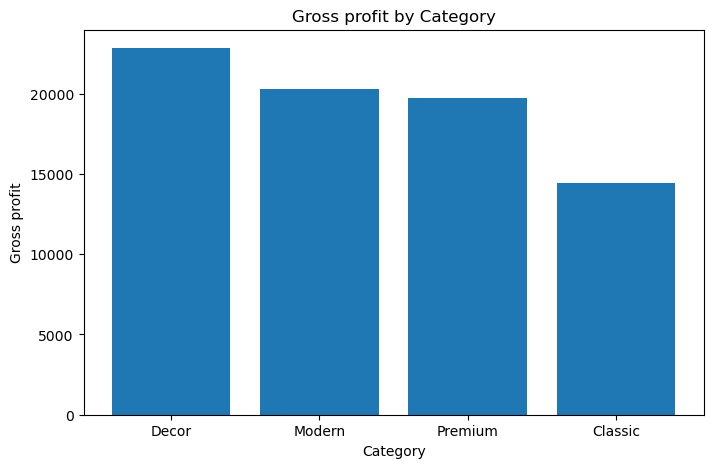

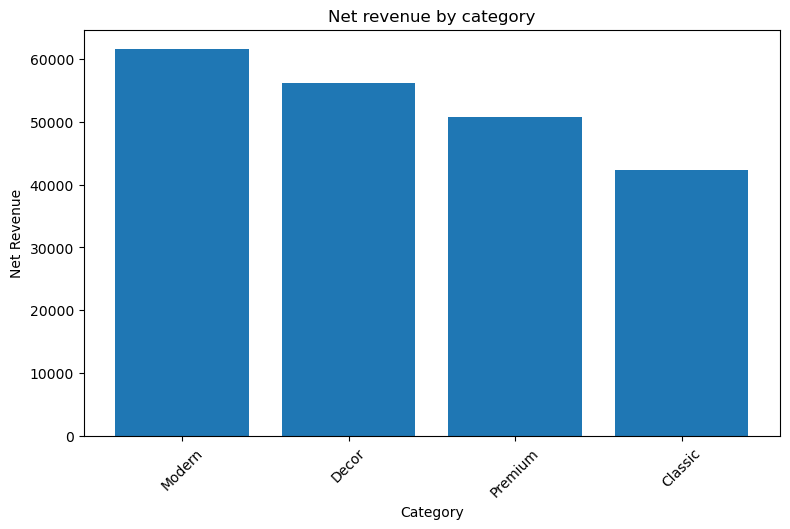

In [61]:
top_profit_categories = category_summary.sort_values("gross_profit",ascending=False)
plt.figure(figsize=(8,5))
plt.bar(top_profit_categories["category"],top_profit_categories["gross_profit"])
plt.title("Gross profit by Category")
plt.xlabel("Category")
plt.ylabel("Gross profit")

category_revenue_sorted = category_summary.sort_values("net_revenue", ascending=False)
plt.figure(figsize=(8,5))
plt.bar(category_revenue_sorted["category"], category_revenue_sorted["net_revenue"])
plt.title("Net revenue by category")
plt.xlabel("Category")
plt.ylabel("Net Revenue")
plt.tight_layout()
plt.xticks(rotation=45)

## 7. Customer Analysis

### 7.1 Create customer summary

In [64]:
customer_summary = analysis_df.groupby(
    ["customer_id", "customer_name", "city", "region", "customer_type", "credit_segment"], as_index=False).agg(
    total_orders=("order_id", "nunique"),
    total_quantity=("quantity", "sum"),
    total_returned_qty=("returned_qty", "sum"),
    total_net_qty=("net_quantity", "sum"),
    gross_revenue=("gross_revenue", "sum"),
    discount_amount=("discount_amount", "sum"),
    net_revenue=("net_revenue", "sum"),
    cost_amount=("cost_amount", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_payment_days=("payment_days", "mean"))

customer_summary["return_rate"] = np.where(
    customer_summary["total_quantity"] != 0,
    customer_summary["total_returned_qty"] / customer_summary["total_quantity"],
    0)

customer_summary["margin_pct"] = np.where(
    customer_summary["net_revenue"] != 0,
    customer_summary["gross_profit"] / customer_summary["net_revenue"],
    0)

customer_summary["discount_pct_effective"] = np.where(
    customer_summary["gross_revenue"] != 0,
    customer_summary["discount_amount"] / customer_summary["gross_revenue"],
    0)

customer_summary["avg_order_value"] = np.where(
    customer_summary["total_orders"] != 0,
    customer_summary["net_revenue"] / customer_summary["total_orders"],
    0)

display(
    customer_summary[
        ["customer_name", "city", "region", "customer_type",
         "total_orders", "net_revenue", "gross_profit",
         "margin_pct", "return_rate", "discount_pct_effective",
         "avg_order_value"]
    ].head()
)

,customer_name,city,region,customer_type,total_orders,net_revenue,gross_profit,margin_pct,return_rate,discount_pct_effective,avg_order_value
0,Gallery_001,Athens,Attica,Gallery,10,1678.9768,573.4668,0.341557,0.000000,0.038095,167.897680
1,Frame_002,Veria,Central Macedonia,Frame Shop,11,1969.5576,683.6176,0.347092,0.035714,0.049739,179.050691
2,Home_003,Patra,Western Greece,Home Decor Store,11,1581.1481,622.0481,0.393415,0.000000,0.028044,143.740736
3,Frame_004,Piraeus,Attica,Frame Shop,10,1499.7993,520.8293,0.347266,0.000000,0.055030,149.979930
4,Gallery_005,Patra,Western Greece,Gallery,16,2061.1090,736.0090,0.357094,0.034014,0.023174,128.819312


### 7.2 Customer performance rankings

In [66]:
display(customer_summary.sort_values("net_revenue", ascending=False)[
    ["customer_name", "city", "region", "customer_type",
     "total_orders", "net_revenue", "gross_profit", "margin_pct"]
].head(10))

display(customer_summary.sort_values("gross_profit", ascending=False)[
    ["customer_name", "city", "region", "customer_type",
     "total_orders", "net_revenue", "gross_profit", "margin_pct", "return_rate"]
].head(10))

,customer_name,city,region,customer_type,total_orders,net_revenue,gross_profit,margin_pct
86,Frame_087,Athens,Attica,Frame Shop,25,4695.8738,1541.3238,0.328229
31,Frame_032,Trikala,Thessaly,Frame Shop,27,4408.7625,1588.8225,0.360378
28,Frame_029,Rethymno,Crete,Frame Shop,25,4243.0620,1531.3920,0.360917
27,Frame_028,Athens,Attica,Frame Shop,24,4233.3912,1453.1412,0.343257
17,Frame_018,Pyrgos,Western Greece,Frame Shop,26,4071.8854,1415.0854,0.347526
84,Frame_085,Agrinio,Western Greece,Frame Shop,25,3886.9014,1453.7214,0.374005
35,Frame_036,Thessaloniki,Central Macedonia,Frame Shop,23,3872.5968,1508.0868,0.389425
21,Frame_022,Chania,Crete,Frame Shop,22,3684.1008,1465.5908,0.397815
34,Gallery_035,Marousi,Attica,Gallery,22,3678.8617,1325.7817,0.360378
32,Frame_033,Katerini,Central Macedonia,Frame Shop,23,3525.4596,1214.7196,0.344556


,customer_name,city,region,customer_type,total_orders,net_revenue,gross_profit,margin_pct,return_rate
31,Frame_032,Trikala,Thessaly,Frame Shop,27,4408.7625,1588.8225,0.360378,0.022951
86,Frame_087,Athens,Attica,Frame Shop,25,4695.8738,1541.3238,0.328229,0.006645
28,Frame_029,Rethymno,Crete,Frame Shop,25,4243.0620,1531.3920,0.360917,0.010676
35,Frame_036,Thessaloniki,Central Macedonia,Frame Shop,23,3872.5968,1508.0868,0.389425,0.000000
21,Frame_022,Chania,Crete,Frame Shop,22,3684.1008,1465.5908,0.397815,0.011152
84,Frame_085,Agrinio,Western Greece,Frame Shop,25,3886.9014,1453.7214,0.374005,0.003472
27,Frame_028,Athens,Attica,Frame Shop,24,4233.3912,1453.1412,0.343257,0.000000
17,Frame_018,Pyrgos,Western Greece,Frame Shop,26,4071.8854,1415.0854,0.347526,0.009740
34,Gallery_035,Marousi,Attica,Gallery,22,3678.8617,1325.7817,0.360378,0.000000
43,Frame_044,Veria,Central Macedonia,Frame Shop,22,3349.9467,1305.3167,0.389653,0.008658


### 7.3 Customer segmentation

In [68]:
rev_q1 = customer_summary["net_revenue"].quantile(0.33)
rev_q2 = customer_summary["net_revenue"].quantile(0.66)

conditions = [customer_summary["net_revenue"] <= rev_q1,
              customer_summary["net_revenue"] <= rev_q2]

choices = ["low_value", "medium_value"]

customer_summary["customer_value_segment"] = np.select(
    conditions,
    choices,
    default="high_value")

customer_summary["discount_relative_segment"] = pd.qcut(
    customer_summary["discount_pct_effective"].rank(method="first"),
    q=3,
    labels = ["low_relative_discount","medium_relative_discount","high_relative_discount"])

mar_q1 = customer_summary["margin_pct"].quantile(0.33)
mar_q2 = customer_summary["margin_pct"].quantile(0.66)

conditions = [customer_summary["gross_profit"] < 0, 
              customer_summary["margin_pct"] <= mar_q1,
              customer_summary["margin_pct"] <= mar_q2]

choices = ["loss_making", "low_margin", "medium_margin"]

customer_summary["profitability_segment"] = np.select(
    conditions,
    choices,
    default="high_margin")

customer_summary["revenue_rank"] = customer_summary["net_revenue"].rank(ascending=False, method="min").astype(int)
customer_summary["profit_rank"] = customer_summary["gross_profit"].rank(ascending=False, method="min").astype(int)
customer_summary["rank_gap_profit_vs_revenue"] = customer_summary["profit_rank"] - customer_summary["revenue_rank"]

top_customer_review = (
    customer_summary
    .sort_values("net_revenue", ascending=False)
    [[
        "customer_name",
        "region",
        "customer_type",
        "total_orders",
        "net_revenue",
        "gross_profit",
        "margin_pct",
        "discount_pct_effective",
        "return_rate",
        "revenue_rank",
        "profit_rank",
        "rank_gap_profit_vs_revenue",
        "customer_value_segment",
        "profitability_segment"
    ]]
    .head(10)
)

display(top_customer_review)

,customer_name,region,customer_type,total_orders,net_revenue,gross_profit,margin_pct,discount_pct_effective,return_rate,revenue_rank,profit_rank,rank_gap_profit_vs_revenue,customer_value_segment,profitability_segment
86,Frame_087,Attica,Frame Shop,25,4695.8738,1541.3238,0.328229,0.058091,0.006645,1,2,1,high_value,low_margin
31,Frame_032,Thessaly,Frame Shop,27,4408.7625,1588.8225,0.360378,0.046585,0.022951,2,1,-1,high_value,medium_margin
28,Frame_029,Crete,Frame Shop,25,4243.0620,1531.3920,0.360917,0.060724,0.010676,3,3,0,high_value,medium_margin
27,Frame_028,Attica,Frame Shop,24,4233.3912,1453.1412,0.343257,0.055177,0.000000,4,7,3,high_value,low_margin
17,Frame_018,Western Greece,Frame Shop,26,4071.8854,1415.0854,0.347526,0.062930,0.009740,5,8,3,high_value,low_margin
84,Frame_085,Western Greece,Frame Shop,25,3886.9014,1453.7214,0.374005,0.048833,0.003472,6,6,0,high_value,medium_margin
35,Frame_036,Central Macedonia,Frame Shop,23,3872.5968,1508.0868,0.389425,0.051878,0.000000,7,4,-3,high_value,high_margin
21,Frame_022,Crete,Frame Shop,22,3684.1008,1465.5908,0.397815,0.059637,0.011152,8,5,-3,high_value,high_margin
34,Gallery_035,Attica,Gallery,22,3678.8617,1325.7817,0.360378,0.034574,0.000000,9,9,0,high_value,medium_margin
32,Frame_033,Central Macedonia,Frame Shop,23,3525.4596,1214.7196,0.344556,0.061744,0.000000,10,16,6,high_value,low_margin


In [69]:
customer_summary[
    (customer_summary["customer_value_segment"] == "high_value") & 
    (customer_summary["profitability_segment"].isin(["loss_making","low_margin"]))
].sort_values("net_revenue",ascending=False)[
    ["customer_name", "region", "net_revenue", "gross_profit", "margin_pct", "discount_pct_effective", "return_rate", "customer_value_segment", "profitability_segment"]
]

,customer_name,region,net_revenue,gross_profit,margin_pct,discount_pct_effective,return_rate,customer_value_segment,profitability_segment
86,Frame_087,Attica,4695.8738,1541.3238,0.328229,0.058091,0.006645,high_value,low_margin
27,Frame_028,Attica,4233.3912,1453.1412,0.343257,0.055177,0.000000,high_value,low_margin
17,Frame_018,Western Greece,4071.8854,1415.0854,0.347526,0.062930,0.009740,high_value,low_margin
32,Frame_033,Central Macedonia,3525.4596,1214.7196,0.344556,0.061744,0.000000,high_value,low_margin
89,Frame_090,Central Macedonia,3466.6770,1156.6870,0.333659,0.064441,0.004329,high_value,low_margin
15,Frame_016,Thessaly,3351.0599,1170.8699,0.349403,0.049702,0.018519,high_value,low_margin
47,Frame_048,Attica,3305.3298,1147.2998,0.347106,0.063709,0.029536,high_value,low_margin
18,Frame_019,Central Macedonia,2957.1151,1038.8551,0.351307,0.033993,0.031579,high_value,low_margin
22,Frame_023,Western Greece,2909.6113,1025.9513,0.352608,0.055781,0.000000,high_value,low_margin


### 7.4 Customer risk and opportunity tables

In [71]:
high_value_low_margin = customer_summary[
    (customer_summary["customer_value_segment"] == "high_value") &
    (customer_summary["profitability_segment"].isin(["loss_making", "low_margin"]))
].sort_values("net_revenue", ascending=False)[
    [
        "customer_name", "region", "total_orders",
        "net_revenue", "gross_profit", "margin_pct",
        "discount_pct_effective", "return_rate",
        "revenue_rank", "profit_rank", "rank_gap_profit_vs_revenue",
        "customer_value_segment", "profitability_segment"
    ]
]
display(high_value_low_margin)

low_value_high_margin = customer_summary[
    (customer_summary["customer_value_segment"] == "low_value") &
    (customer_summary["profitability_segment"] == "high_margin")
].sort_values("gross_profit", ascending=False)[
    [
        "customer_name", "region", "total_orders",
        "net_revenue", "gross_profit", "margin_pct",
        "discount_pct_effective", "return_rate",
        "customer_value_segment", "profitability_segment"
    ]
]
display(low_value_high_margin)

return_margin_risk = customer_summary[
    (customer_summary["total_orders"] >= 10) &
    (customer_summary["return_rate"] > customer_summary["return_rate"].median()) &
    (customer_summary["margin_pct"] < customer_summary["margin_pct"].median())
].sort_values(["return_rate", "margin_pct"], ascending=[False, True])[
    [
        "customer_name", "region", "total_orders",
        "return_rate", "margin_pct",
        "net_revenue", "gross_profit"
    ]
]
display(return_margin_risk)

,customer_name,region,total_orders,net_revenue,gross_profit,margin_pct,discount_pct_effective,return_rate,revenue_rank,profit_rank,rank_gap_profit_vs_revenue,customer_value_segment,profitability_segment
86,Frame_087,Attica,25,4695.8738,1541.3238,0.328229,0.058091,0.006645,1,2,1,high_value,low_margin
27,Frame_028,Attica,24,4233.3912,1453.1412,0.343257,0.055177,0.000000,4,7,3,high_value,low_margin
17,Frame_018,Western Greece,26,4071.8854,1415.0854,0.347526,0.062930,0.009740,5,8,3,high_value,low_margin
32,Frame_033,Central Macedonia,23,3525.4596,1214.7196,0.344556,0.061744,0.000000,10,16,6,high_value,low_margin
89,Frame_090,Central Macedonia,20,3466.6770,1156.6870,0.333659,0.064441,0.004329,11,18,7,high_value,low_margin
15,Frame_016,Thessaly,19,3351.0599,1170.8699,0.349403,0.049702,0.018519,13,17,4,high_value,low_margin
47,Frame_048,Attica,18,3305.3298,1147.2998,0.347106,0.063709,0.029536,16,19,3,high_value,low_margin
18,Frame_019,Central Macedonia,18,2957.1151,1038.8551,0.351307,0.033993,0.031579,23,26,3,high_value,low_margin
22,Frame_023,Western Greece,21,2909.6113,1025.9513,0.352608,0.055781,0.000000,25,29,4,high_value,low_margin


,customer_name,region,total_orders,net_revenue,gross_profit,margin_pct,discount_pct_effective,return_rate,customer_value_segment,profitability_segment
62,Home_063,Thessaly,12,1787.4728,716.5728,0.400886,0.028674,0.000000,low_value,high_margin
11,Gallery_012,Western Greece,11,1676.4192,670.0392,0.399685,0.040533,0.000000,low_value,high_margin
78,Frame_079,Thessaly,12,1683.2285,663.7385,0.394325,0.034281,0.000000,low_value,high_margin
2,Home_003,Western Greece,11,1581.1481,622.0481,0.393415,0.028044,0.000000,low_value,high_margin
66,Home_067,Western Greece,13,1512.1218,608.0518,0.402118,0.016538,0.000000,low_value,high_margin
48,Home_049,Thessaly,10,1560.1956,603.5156,0.386820,0.036837,0.028037,low_value,high_margin
65,Gallery_066,Western Greece,10,1311.5516,513.9316,0.391850,0.041224,0.028037,low_value,high_margin
79,Gift_080,Thessaly,10,1244.1064,512.2864,0.411771,0.025925,0.022989,low_value,high_margin
9,Gallery_010,Western Greece,10,1290.1889,507.9589,0.393709,0.037435,0.031915,low_value,high_margin
64,Gift_065,Thessaly,9,1017.5624,391.0024,0.384254,0.042490,0.035294,low_value,high_margin


,customer_name,region,total_orders,return_rate,margin_pct,net_revenue,gross_profit
51,Frame_052,Crete,13,0.037736,0.331606,2363.8456,783.8656
1,Frame_002,Central Macedonia,11,0.035714,0.347092,1969.5576,683.6176
4,Gallery_005,Western Greece,16,0.034014,0.357094,2061.1090,736.0090
54,Frame_055,Attica,11,0.033333,0.366158,1571.6213,575.4613
18,Frame_019,Central Macedonia,18,0.031579,0.351307,2957.1151,1038.8551
47,Frame_048,Attica,18,0.029536,0.347106,3305.3298,1147.2998
57,Home_058,Attica,14,0.028571,0.343239,2092.6653,718.2853
31,Frame_032,Thessaly,27,0.022951,0.360378,4408.7625,1588.8225
30,Home_031,Attica,16,0.018634,0.364142,2480.6178,903.2978
15,Frame_016,Thessaly,19,0.018519,0.349403,3351.0599,1170.8699


### 7.5 Customer mix by region and type

### Region summary

In [74]:
region_summary = customer_summary.groupby("region", as_index=False).agg(
    customers=("customer_id", "count"),
    total_orders=("total_orders", "sum"),
    net_revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_payment_days=("avg_payment_days", "mean")
)

region_summary["margin_pct"] = np.where(
    region_summary["net_revenue"] != 0,
    region_summary["gross_profit"] / region_summary["net_revenue"],
    0
)

display(region_summary.sort_values("net_revenue", ascending=False))

,region,customers,total_orders,net_revenue,gross_profit,avg_payment_days,margin_pct
0,Attica,22,317,52885.2063,19063.6463,41.463076,0.360472
4,Western Greece,20,304,44892.2335,16684.5335,40.614342,0.371657
1,Central Macedonia,18,273,42687.5954,15698.3154,39.280063,0.367749
3,Thessaly,17,238,36799.7331,13507.8731,41.684792,0.367064
2,Crete,13,209,33487.8994,12322.2594,40.086941,0.367962


### Type summary

In [76]:
type_summary = customer_summary.groupby("customer_type", as_index=False).agg(
    customers=("customer_id", "count"),
    total_orders=("total_orders", "sum"),
    net_revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_payment_days=("avg_payment_days", "mean"),
    avg_return_rate=("return_rate", "mean")
)

type_summary["margin_pct"] = np.where(
    type_summary["net_revenue"] != 0,
    type_summary["gross_profit"] / type_summary["net_revenue"],
    0
)

display(type_summary.sort_values("net_revenue", ascending=False))

,customer_type,customers,total_orders,net_revenue,gross_profit,avg_payment_days,avg_return_rate,margin_pct
0,Frame Shop,38,690,111916.2608,40601.4008,41.040117,0.010197,0.362784
3,Home Decor Store,25,322,48665.3496,17949.3396,39.214354,0.009637,0.368832
2,Gift Shop,15,183,27265.9165,10151.6265,42.398245,0.005600,0.372319
1,Gallery,12,146,22905.1408,8574.2608,40.452531,0.020905,0.374338


### 7.6 Customer visualizations

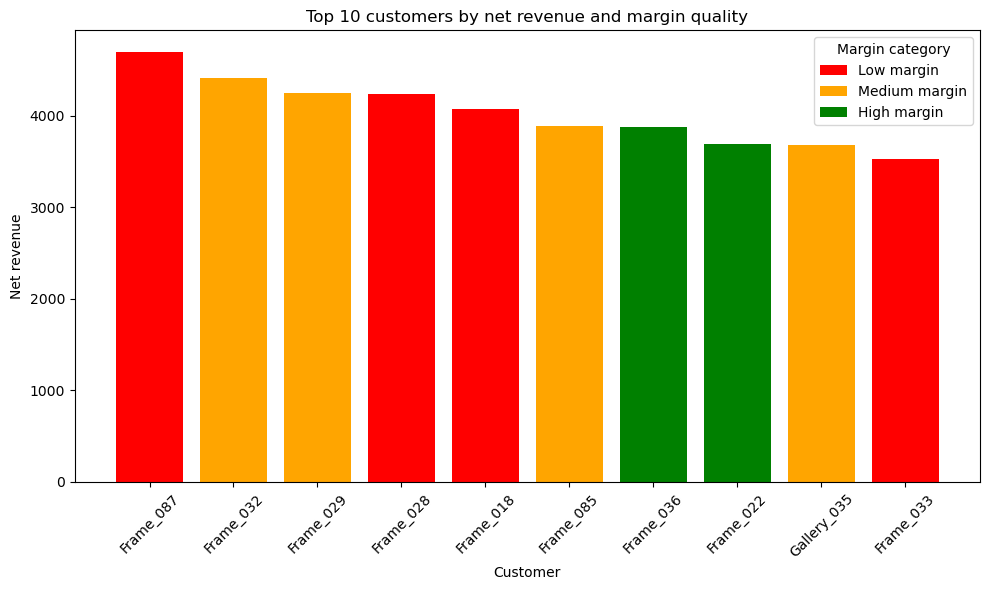

In [78]:
top_customers = customer_summary.sort_values(
    "net_revenue", ascending=False
).head(10)

color_map = {
    "high_margin": "green",
    "medium_margin": "orange",
    "low_margin": "red"
}

colors = top_customers["profitability_segment"].map(color_map)

plt.figure(figsize=(10, 6))
plt.bar(top_customers["customer_name"], top_customers["net_revenue"], color=colors)
plt.title("Top 10 customers by net revenue and margin quality")
plt.xlabel("Customer")
plt.ylabel("Net revenue")
plt.xticks(rotation=45)
plt.tight_layout()
from matplotlib.patches import Patch


plt.bar(
    top_customers["customer_name"],
    top_customers["net_revenue"],
    color=colors
)

legend_elements = [
    Patch(facecolor="red", label="Low margin"),
    Patch(facecolor="orange", label="Medium margin"),
    Patch(facecolor="green", label="High margin")
]

plt.legend(
    handles=legend_elements,
    title="Margin category"
)

plt.tight_layout()

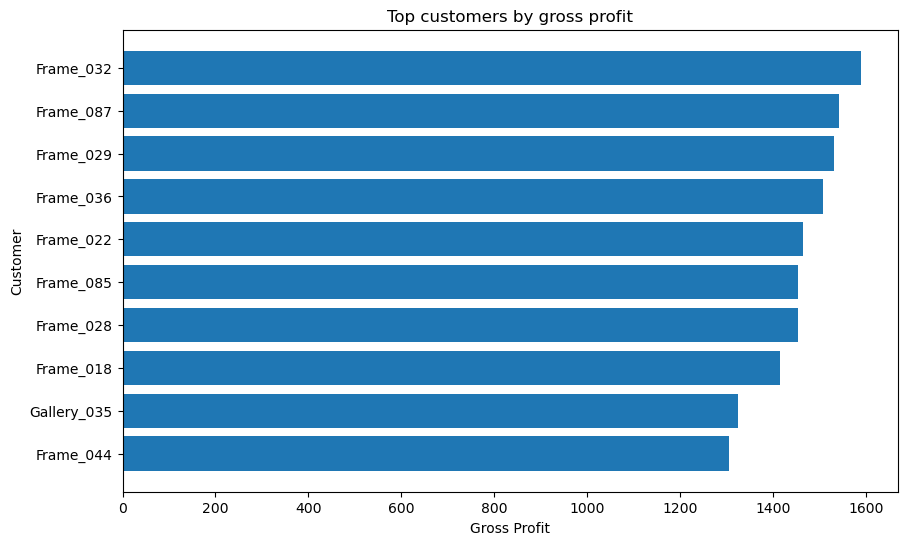

In [79]:
top_customers_profit = customer_summary.sort_values("gross_profit", ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.barh(top_customers_profit["customer_name"],top_customers_profit["gross_profit"])
plt.title("Top customers by gross profit")
plt.ylabel("Customer")
plt.xlabel("Gross Profit")
plt.gca().invert_yaxis()


Text(0.5, 0, 'Region')

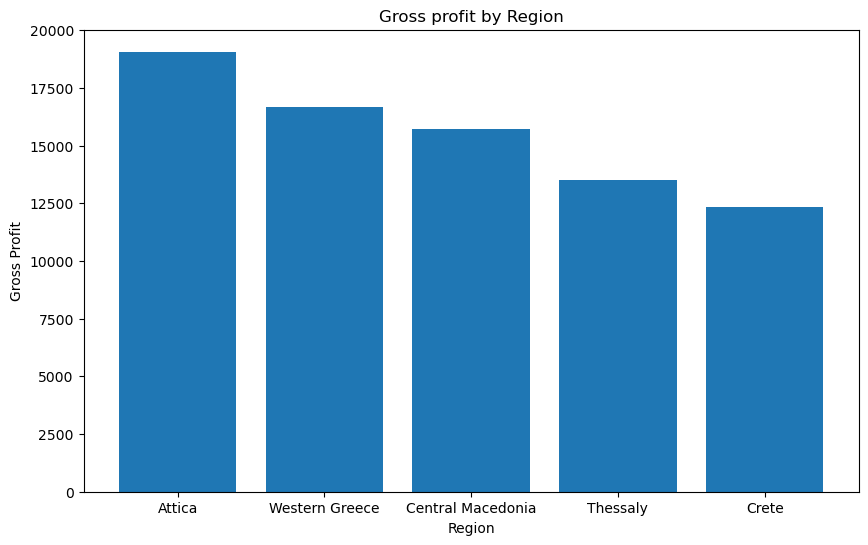

In [80]:
top_regions_profit = region_summary.sort_values("gross_profit",ascending=False)
plt.figure(figsize=(10,6))
plt.bar(top_regions_profit["region"],top_regions_profit["gross_profit"])
plt.title("Gross profit by Region")
plt.ylabel("Gross Profit")
plt.xlabel("Region")

# 8. Time-Based Analysis

### 8.1 Monthly and quarterly summaries

In [83]:
monthly_summary = analysis_df.groupby("order_month", as_index=False).agg(
    total_orders=("order_id","nunique"),
    total_qty=("quantity","sum"),
    total_returned_qty=("returned_qty","sum"),
    net_revenue=("net_revenue","sum"),
    gross_profit=("gross_profit","sum"),
    discount_amount=("discount_amount","sum")
)

monthly_summary["return_rate"] = np.where(
    monthly_summary["total_qty"] != 0,
    monthly_summary["total_returned_qty"] / monthly_summary["total_qty"],
    0
)

monthly_summary["margin_pct"] = np.where(
    monthly_summary["net_revenue"] != 0,
    monthly_summary["gross_profit"] / monthly_summary["net_revenue"],
    0
)

monthly_summary["discount_pct_effective"] = np.where(
    monthly_summary["net_revenue"] != 0,
    monthly_summary["discount_amount"] / monthly_summary["net_revenue"],
    0
)

monthly_summary = monthly_summary.sort_values("order_month", ascending=True).reset_index(drop=True)

display(monthly_summary)

,order_month,total_orders,total_qty,total_returned_qty,net_revenue,gross_profit,discount_amount,return_rate,margin_pct,discount_pct_effective
0,2025-01,79,725,10,10257.2106,3904.2306,312.5708,0.013793,0.380633,0.030473
1,2025-02,97,954,13,13876.1489,5285.7689,507.6008,0.013627,0.380925,0.036581
2,2025-03,97,1171,9,17168.2782,5974.3982,724.3643,0.007686,0.347991,0.042192
3,2025-04,94,1105,12,15404.8189,5709.7589,778.3293,0.010860,0.370648,0.050525
4,2025-05,104,1298,13,19530.4899,7038.8799,867.2567,0.010015,0.360405,0.044405
5,2025-06,111,1225,14,18065.9430,6704.7030,795.6878,0.011429,0.371124,0.044044
6,2025-07,104,1182,10,18172.3872,6664.3972,709.8149,0.008460,0.366732,0.039060
7,2025-08,105,1175,16,17281.2461,6418.8661,825.5328,0.013617,0.371435,0.047770
8,2025-09,91,969,10,14114.0309,5144.3909,597.6496,0.010320,0.364488,0.042344
9,2025-10,139,1547,16,22242.7757,8192.1157,927.0166,0.010343,0.368305,0.041677


In [84]:
quarterly_summary = analysis_df.groupby("order_quarter", as_index=False).agg(
    total_orders=("order_id","nunique"),
    total_qty=("quantity","sum"),
    total_returned_qty=("returned_qty","sum"),
    net_revenue=("net_revenue","sum"),
    gross_profit=("gross_profit","sum"),
    discount_amount=("discount_amount","sum")
)

quarterly_summary["return_rate"] = np.where(
    quarterly_summary["total_qty"] != 0,
    quarterly_summary["total_returned_qty"] / quarterly_summary["total_qty"],
    0
)

quarterly_summary["margin_pct"] = np.where(
    quarterly_summary["net_revenue"] != 0,
    quarterly_summary["gross_profit"] / quarterly_summary["net_revenue"],
    0
)

quarterly_summary["discount_pct_effective"] = np.where(
    quarterly_summary["net_revenue"] != 0,
    quarterly_summary["discount_amount"] / quarterly_summary["net_revenue"],
    0
)

quarterly_summary = quarterly_summary.sort_values("order_quarter").reset_index(drop=True)
display(quarterly_summary)

,order_quarter,total_orders,total_qty,total_returned_qty,net_revenue,gross_profit,discount_amount,return_rate,margin_pct,discount_pct_effective
0,2025Q1,238,2850,32,41301.6377,15164.3977,1544.5359,0.011228,0.367162,0.037396
1,2025Q2,271,3628,39,53001.2518,19453.3418,2441.2738,0.010750,0.367036,0.046061
2,2025Q3,252,3326,36,49567.6642,18227.6542,2132.9973,0.010824,0.367733,0.043032
3,2025Q4,297,4555,36,66882.1140,24431.2340,3259.7778,0.007903,0.365288,0.048739


### 8.2 Monthly revenue and gross profit trend

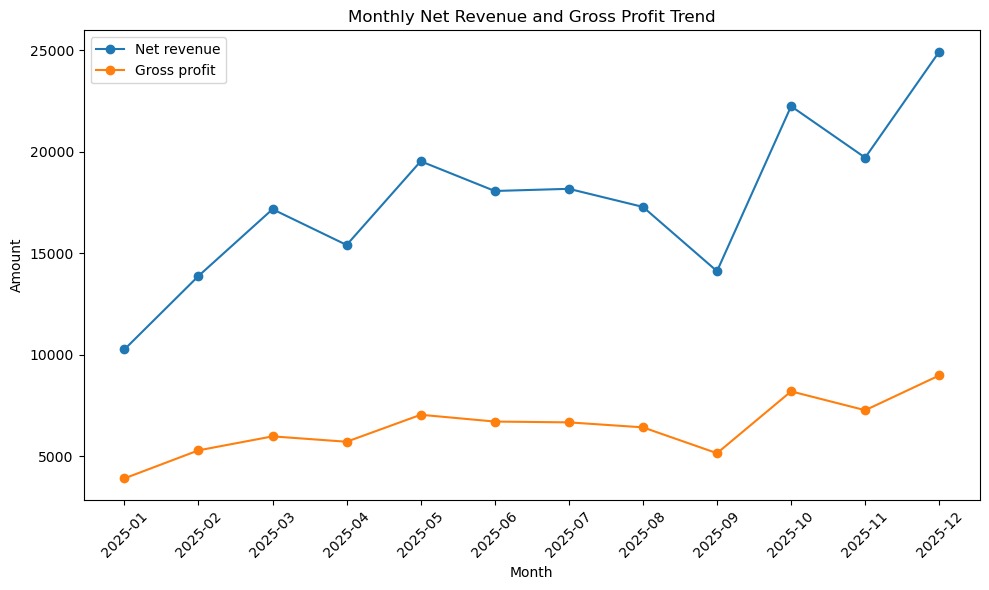

In [86]:
plt.figure(figsize=(10, 6))

plt.plot(monthly_summary["order_month"], monthly_summary["net_revenue"], marker="o", label="Net revenue")
plt.plot(monthly_summary["order_month"], monthly_summary["gross_profit"], marker="o", label="Gross profit")

plt.title("Monthly Net Revenue and Gross Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 8.3 Monthly return rate trend

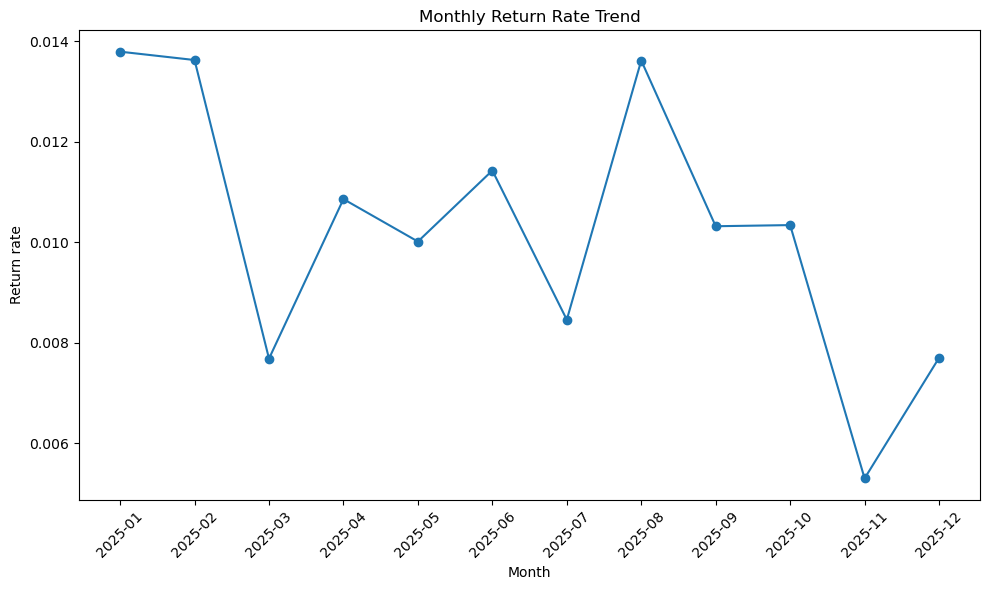

In [88]:
plt.figure(figsize=(10, 6))

plt.plot(monthly_summary["order_month"], monthly_summary["return_rate"], marker="o")

plt.title("Monthly Return Rate Trend")
plt.xlabel("Month")
plt.ylabel("Return rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8.4 Quarterly performance overview

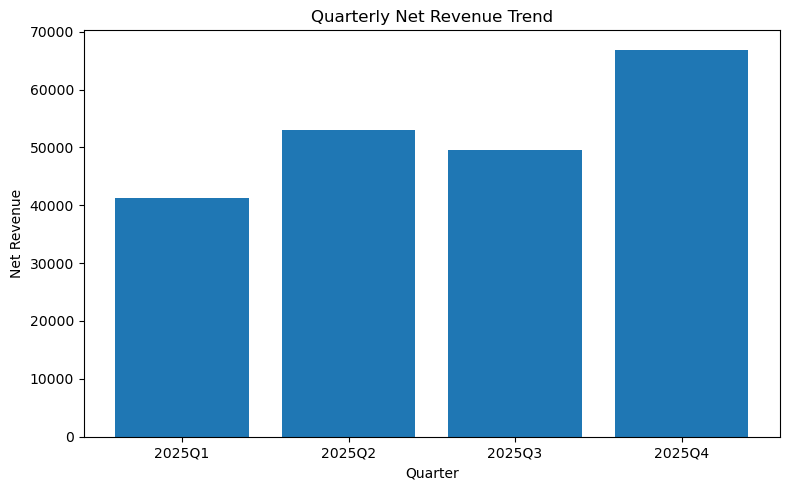

In [90]:
plt.figure(figsize=(8, 5))

plt.bar(quarterly_summary["order_quarter"], quarterly_summary["net_revenue"])

plt.title("Quarterly Net Revenue Trend")
plt.xlabel("Quarter")
plt.ylabel("Net Revenue")
plt.tight_layout()
plt.show()

### 8.5 Time analysis insights

Sales performance increased strongly toward the end of the year. Q4 was the strongest quarter by both net revenue and gross profit, while December was the strongest individual month. Return rate was lower in the final months, which may indicate improved order quality, customer mix or operational handling. Margins remained relatively stable, meaning the year-end growth was mainly volume-driven rather than margin-driven.

## 9. Inventory and Reorder Analysis

This section analyses inventory risk by combining current stock levels with product movement, average monthly demand and stock coverage. The goal is to identify products that may require reorder action, products at risk of stockout, and products that may represent overstock risk.

### 9.1 Create inventory summary and stock coverage

In [96]:
inventory_summary = product_summary.copy()

inventory_summary["avg_monthly_net_qty"] = inventory_summary["total_net_qty"] / 12

inventory_summary["stock_coverage_months"] = np.where(
    inventory_summary["avg_monthly_net_qty"] != 0,
    inventory_summary["current_stock"] / inventory_summary["avg_monthly_net_qty"],
    np.inf
)

display(
    inventory_summary[
        [
            "product_id",
            "product_name",
            "category",
            "total_net_qty",
            "avg_monthly_net_qty",
            "current_stock",
            "reorder_point",
            "stock_coverage_months"
        ]
    ].head()
)

,product_id,product_name,category,total_net_qty,avg_monthly_net_qty,current_stock,reorder_point,stock_coverage_months
0,P001,Wood Frame V1,Classic,500,41.666667,239,48,5.736000
1,P002,Wood Frame V2,Classic,432,36.000000,193,59,5.361111
2,P003,Wood Frame V3,Classic,563,46.916667,127,35,2.706927
3,P004,Metal Frame V1,Classic,537,44.750000,44,76,0.983240
4,P005,Metal Frame V2,Classic,455,37.916667,190,58,5.010989


### 9.2 Reorder priority classification

In [98]:
conditions = [
    (inventory_summary["current_stock"] <= inventory_summary["reorder_point"]) &
    (inventory_summary["avg_monthly_net_qty"] > 0),
    
    (inventory_summary["stock_coverage_months"] < 1.5) & 
    (inventory_summary["avg_monthly_net_qty"] > 0),
    
    (inventory_summary["stock_coverage_months"] < 3) & 
    (inventory_summary["avg_monthly_net_qty"] > 0),
    
    inventory_summary["avg_monthly_net_qty"] == 0    
]

choices = [
    "urgent_reorder",
    "high_risk_stockout",
    "watchlist",
    "no_recent_demand"
]
    
inventory_summary["reorder_priority"] = np.select(
    conditions,
    choices,
    default="healthy"
)

In [99]:
reorder_priority_order = [
    "urgent_reorder",
    "high_risk_stockout",
    "watchlist",
    "healthy",
    "no_recent_demand"
]

reorder_priority_summary = (
    inventory_summary["reorder_priority"]
    .value_counts()
    .reindex(reorder_priority_order, fill_value=0)
    .reset_index()
)

reorder_priority_summary.columns = ["reorder_priority", "product_count"]

display(reorder_priority_summary)

,reorder_priority,product_count
0,urgent_reorder,7
1,high_risk_stockout,0
2,watchlist,4
3,healthy,25
4,no_recent_demand,0


In [100]:
products_to_review = inventory_summary[
    inventory_summary["reorder_priority"].isin(
        ["urgent_reorder", "high_risk_stockout", "watchlist"]
    )
].shape[0]

total_products = inventory_summary["product_id"].nunique()

inventory_review_pct = products_to_review / total_products

inventory_review_summary = pd.DataFrame({
    "metric": [
        "products requiring reorder or review",
        "total products",
        "inventory review share"
    ],
    "value": [
        products_to_review,
        total_products,
        round(inventory_review_pct * 100, 2)
    ]
})

display(inventory_review_summary)

,metric,value
0,products requiring reorder or review,11.00
1,total products,36.00
2,inventory review share,30.56


### 9.3 Movement segmentation and overstock risk

In [102]:
low_th = inventory_summary["total_net_qty"].quantile(0.25)
high_th = inventory_summary["total_net_qty"].quantile(0.75)

conditions = [
    inventory_summary["total_net_qty"] <= low_th,
    inventory_summary["total_net_qty"] >= high_th
]

choices = [
    "slow_mover",
    "fast_mover"
]

inventory_summary["movement_segment"] = np.select(
    conditions,
    choices,
    default="medium_mover"
)

movement_segment_summary = (
    inventory_summary["movement_segment"]
    .value_counts()
    .reset_index()
)

movement_segment_summary.columns = ["movement_segment", "product_count"]

display(movement_segment_summary)

,movement_segment,product_count
0,medium_mover,18
1,fast_mover,9
2,slow_mover,9


In [103]:
inventory_summary["overstock_risk"] = np.where(
    (inventory_summary["movement_segment"] == "slow_mover") &
    (inventory_summary["stock_coverage_months"] > 6),
    True,
    False
)

overstock_risk_summary = (
    inventory_summary["overstock_risk"]
    .value_counts()
    .reset_index()
)

overstock_risk_summary.columns = ["overstock_risk", "product_count"]

display(overstock_risk_summary)

,overstock_risk,product_count
0,False,29
1,True,7


### 9.4 Stockout and overstock review lists

In [105]:
# Immediate reorder list
immediate_reorder_list = (
    inventory_summary[
        inventory_summary["reorder_priority"].isin(["urgent_reorder", "high_risk_stockout"])
    ]
    .sort_values(["gross_profit", "stock_coverage_months"], ascending=[False, True])
    [
        [
            "product_name",
            "category",
            "current_stock",
            "avg_monthly_net_qty",
            "stock_coverage_months",
            "gross_profit",
            "reorder_priority"
        ]
    ]
)

display(immediate_reorder_list)

,product_name,category,current_stock,avg_monthly_net_qty,stock_coverage_months,gross_profit,reorder_priority
33,Art Frame V1,Decor,47,29.833333,1.575419,3471.1164,urgent_reorder
35,Art Frame V3,Decor,58,33.666667,1.722772,2961.3153,urgent_reorder
25,White Frame V2,Modern,43,30.416667,1.413699,2046.4860,urgent_reorder
19,Minimal Frame V2,Modern,48,43.083333,1.114120,1925.8999,urgent_reorder
24,White Frame V1,Modern,66,36.666667,1.800000,1801.5966,urgent_reorder
3,Metal Frame V1,Classic,44,44.750000,0.983240,1414.9904,urgent_reorder
17,Oak Frame V3,Premium,50,25.666667,1.948052,1286.0115,urgent_reorder


In [106]:
# Critical stockout risk list
inventory_summary["stockout_risk"] = np.where(
    (inventory_summary["movement_segment"] == "fast_mover") &
    (inventory_summary["stock_coverage_months"] < 2),
    True,
    False
)
stockout_risk_list = (
    inventory_summary[inventory_summary["stockout_risk"] == True]
    .sort_values(["stock_coverage_months", "gross_profit"], ascending=[True, False])
    [
        [
            "product_name",
            "category",
            "movement_segment",
            "total_net_qty",
            "avg_monthly_net_qty",
            "current_stock",
            "stock_coverage_months",
            "gross_profit",
            "margin_pct"
        ]
    ]
)

display(stockout_risk_list)

,product_name,category,movement_segment,total_net_qty,avg_monthly_net_qty,current_stock,stock_coverage_months,gross_profit,margin_pct
3,Metal Frame V1,Classic,fast_mover,537,44.750000,44,0.98324,1414.9904,0.300982
19,Minimal Frame V2,Modern,fast_mover,517,43.083333,48,1.11412,1925.8999,0.329951


In [107]:
# Overstock risk list
over_stock_list = (
    inventory_summary[inventory_summary["overstock_risk"] == True]
    .sort_values("stock_coverage_months", ascending=False)
    [
        [
            "product_name",
            "category",
            "current_stock",
            "avg_monthly_net_qty",
            "stock_coverage_months",
            "net_revenue",
            "gross_profit"
        ]
    ]
)

display(over_stock_list)

,product_name,category,current_stock,avg_monthly_net_qty,stock_coverage_months,net_revenue,gross_profit
32,Poster Frame V3,Decor,225,24.500000,9.183673,4981.1730,2039.0130
15,Oak Frame V1,Premium,136,18.250000,7.452055,4049.2611,1913.4711
30,Poster Frame V1,Decor,191,26.250000,7.276190,4634.2087,1971.9187
11,Gold Frame V3,Premium,157,22.916667,6.850909,5121.7685,1317.8585
31,Poster Frame V2,Decor,181,27.333333,6.621951,4186.5740,1672.7340
13,Silver Frame V2,Premium,168,25.500000,6.588235,5289.0600,2569.1800
10,Gold Frame V2,Premium,142,22.666667,6.264706,4233.5990,1136.5090


In [108]:
high_profit_th = inventory_summary["gross_profit"].quantile(0.75)

strategic_products_list = (
    inventory_summary[
        (inventory_summary["movement_segment"] == "fast_mover") &
        (inventory_summary["gross_profit"] >= high_profit_th)
    ]
    .sort_values("gross_profit", ascending=False)
    [
        [
            "product_name",
            "category",
            "total_net_qty",
            "current_stock",
            "stock_coverage_months",
            "gross_profit",
            "margin_pct"
        ]
    ]
)

display(strategic_products_list)

,product_name,category,total_net_qty,current_stock,stock_coverage_months,gross_profit,margin_pct
18,Minimal Frame V1,Modern,483,151,3.751553,3052.2444,0.447901
21,Black Frame V1,Modern,565,132,2.803540,2605.3882,0.320725


### 9.5 Category-level inventory view

In [110]:
category_inventory_summary = inventory_summary.groupby("category", as_index=False).agg(
    products=("product_id", "count"),
    total_stock=("current_stock", "sum"),
    total_reorder_point=("reorder_point", "sum"),
    total_net_qty=("total_net_qty", "sum"),
    avg_monthly_net_qty=("avg_monthly_net_qty", "sum"),
    net_revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum")
)

category_inventory_summary["stock_coverage_months"] = np.where(
    category_inventory_summary["avg_monthly_net_qty"] != 0,
    category_inventory_summary["total_stock"] / category_inventory_summary["avg_monthly_net_qty"],
    np.inf
)

category_inventory_summary["margin_pct"] = np.where(
    category_inventory_summary["net_revenue"] != 0,
    category_inventory_summary["gross_profit"] / category_inventory_summary["net_revenue"],
    0
)

display(
    category_inventory_summary.sort_values("stock_coverage_months")
)

,category,products,total_stock,total_reorder_point,total_net_qty,avg_monthly_net_qty,net_revenue,gross_profit,stock_coverage_months,margin_pct
2,Modern,9,1015,641,4012,334.333333,61550.6991,20298.3391,3.035892,0.329782
0,Classic,9,1409,522,4263,355.250000,42247.7515,14426.2915,3.966221,0.341469
1,Decor,9,1395,569,3261,271.750000,56185.8361,22835.7861,5.133395,0.406433
3,Premium,9,1410,464,2680,223.333333,50768.3810,19716.2110,6.313433,0.388356


## 9.6 Inventory visualization

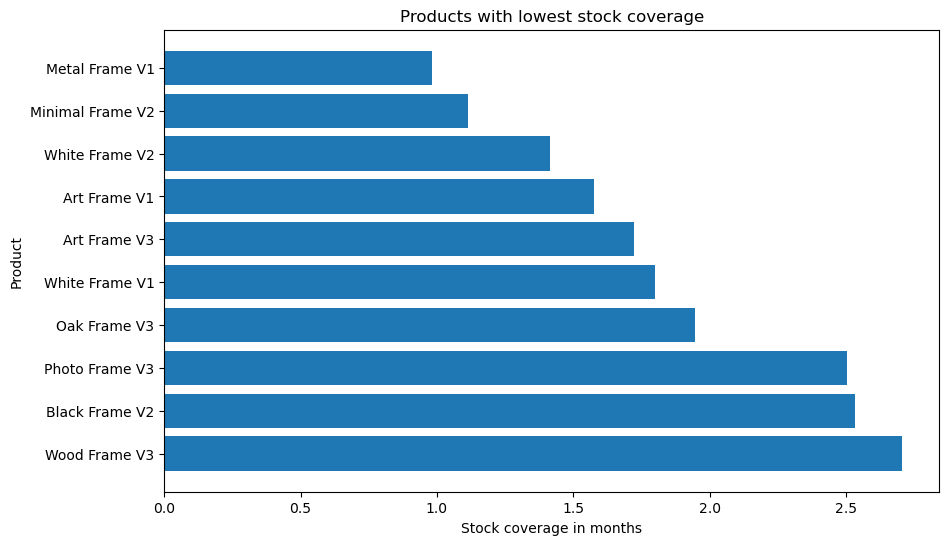

In [112]:
top_stock_pressure = inventory_summary.sort_values("stock_coverage_months").head(10)
plt.figure(figsize=(10,6))
plt.barh(top_stock_pressure["product_name"], top_stock_pressure["stock_coverage_months"])
plt.title("Products with lowest stock coverage")
plt.xlabel("Stock coverage in months")
plt.ylabel("Product")
plt.gca().invert_yaxis()

## 9.7 Inventory Insights

The inventory analysis shows that 11 out of 36 products require either immediate reorder action or closer monitoring. This means that about 30% of the product portfolio is currently exposed to reorder pressure, which is more informative than looking only at the absolute number of urgent products.

Urgent reorder products include several commercially important and profitable items, so stock shortages could lead to lost sales. At the same time, the overstock review list shows products with slow movement and high stock coverage, which may tie up working capital.

These findings should be interpreted as point-in-time inventory signals, because the dataset uses current stock levels and does not include supplier lead times, freight costs or replenishment history.

## 10. Sales Channel, Sales Rep and Discount Analysis

### 10.1 Channel performance

,channel,total_orders,net_revenue,gross_profit,margin_pct,return_rate,discount_pct_effective,avg_payment_days
2,Wholesale,475,127882.2345,47061.3345,0.368005,0.011082,0.040997,39.963768
0,Direct,217,41604.7933,15059.6733,0.361970,0.009828,0.045914,41.460674
1,Phone Order,217,41265.6399,15155.6199,0.367270,0.006674,0.042103,40.698113


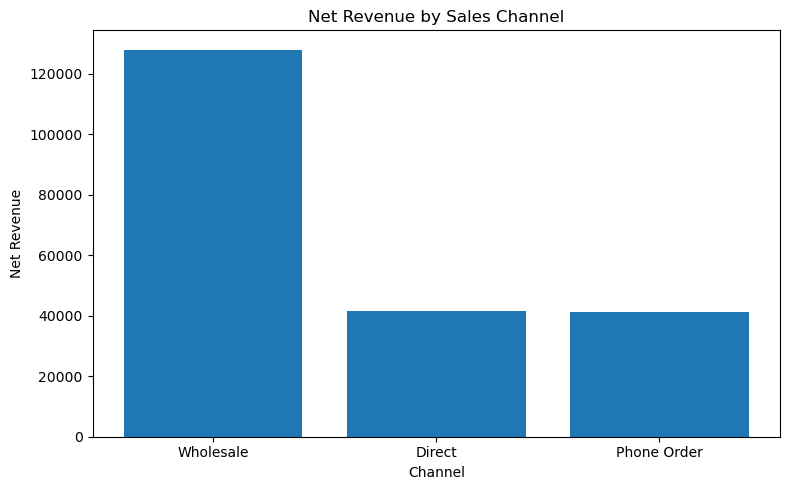

In [116]:
channel_summary = analysis_df.groupby("channel", as_index=False).agg(
    total_orders=("order_id", "nunique"),
    total_quantity=("quantity", "sum"),
    discount_amount=("discount_amount", "sum"),
    total_returned_qty=("returned_qty", "sum"),
    gross_revenue=("gross_revenue", "sum"),
    net_revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_discount_pct=("discount_pct", "mean"),
    avg_payment_days=("payment_days", "mean")
)

channel_summary["return_rate"] = np.where(
    channel_summary["total_quantity"] != 0,
    channel_summary["total_returned_qty"] / channel_summary["total_quantity"],
    0
)

channel_summary["margin_pct"] = np.where(
    channel_summary["net_revenue"] != 0,
    channel_summary["gross_profit"] / channel_summary["net_revenue"],
    0
)

channel_summary["discount_pct_effective"] = np.where(
    channel_summary["gross_revenue"] != 0,
    channel_summary["discount_amount"] / channel_summary["gross_revenue"],
    0
)

channel_performance = channel_summary.sort_values("net_revenue", ascending=False)[
    [
        "channel",
        "total_orders",
        "net_revenue",
        "gross_profit",
        "margin_pct",
        "return_rate",
        "discount_pct_effective",
        "avg_payment_days"
    ]
]

display(channel_performance)

channel_revenue_sorted = channel_summary.sort_values("net_revenue", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(channel_revenue_sorted["channel"], channel_revenue_sorted["net_revenue"])
plt.title("Net Revenue by Sales Channel")
plt.xlabel("Channel")
plt.ylabel("Net Revenue")
plt.tight_layout()
plt.show()

Wholesale is the strongest sales channel by net revenue and also contributes the largest gross profit. However, margin percentage and payment days are relatively similar across channels, meaning that the main difference between channels comes mostly from sales volume rather than profitability per euro of revenue.

### 10.2 Sales rep performance

In [119]:
sales_rep_summary = analysis_df.groupby("sales_rep", as_index=False).agg(
    total_orders=("order_id", "nunique"),
    total_customers=("customer_id", "nunique"),
    total_qty=("quantity", "sum"),
    total_returned_qty=("returned_qty", "sum"),
    gross_revenue=("gross_revenue", "sum"),
    net_revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    discount_amount=("discount_amount", "sum"),
    avg_payment_days=("payment_days", "mean"),
    avg_discount_pct=("discount_pct", "mean")
)

sales_rep_summary["margin_pct"] = np.where(
    sales_rep_summary["net_revenue"] != 0,
    sales_rep_summary["gross_profit"] / sales_rep_summary["net_revenue"],
    0
)

sales_rep_summary["return_rate"] = np.where(
    sales_rep_summary["total_qty"] != 0,
    sales_rep_summary["total_returned_qty"] / sales_rep_summary["total_qty"],
    0
)

sales_rep_summary["discount_pct_effective"] = np.where(
    sales_rep_summary["gross_revenue"] != 0,
    sales_rep_summary["discount_amount"] / sales_rep_summary["gross_revenue"],
    0
)


In [120]:
sales_rep_summary["revenue_rank"] = sales_rep_summary["net_revenue"].rank(
    ascending=False, method="min"
).astype(int)

sales_rep_summary["profit_rank"] = sales_rep_summary["gross_profit"].rank(
    ascending=False, method="min"
).astype(int)

sales_rep_summary["rank_gap_profit_vs_revenue"] = (
    sales_rep_summary["profit_rank"] - sales_rep_summary["revenue_rank"]
)

In [121]:
sales_rep_performance = sales_rep_summary.sort_values("gross_profit", ascending=False)[
    [
        "sales_rep",
        "total_orders",
        "total_customers",
        "net_revenue",
        "gross_profit",
        "margin_pct",
        "discount_pct_effective",
        "avg_payment_days",
        "revenue_rank",
        "profit_rank",
        "rank_gap_profit_vs_revenue"
    ]
]

display(sales_rep_performance)

,sales_rep,total_orders,total_customers,net_revenue,gross_profit,margin_pct,discount_pct_effective,avg_payment_days,revenue_rank,profit_rank,rank_gap_profit_vs_revenue
3,Nikos,260,88,53923.8515,20342.9115,0.377253,0.040714,40.626822,2,1,-1
0,Eleni,270,87,53693.9683,19922.5983,0.371040,0.040201,40.646552,3,2,-1
1,Giorgos,262,88,54476.1890,19480.7390,0.357601,0.043070,40.525568,1,3,2
2,Maria,258,89,48658.6589,17530.3789,0.360273,0.044993,39.747634,4,4,0


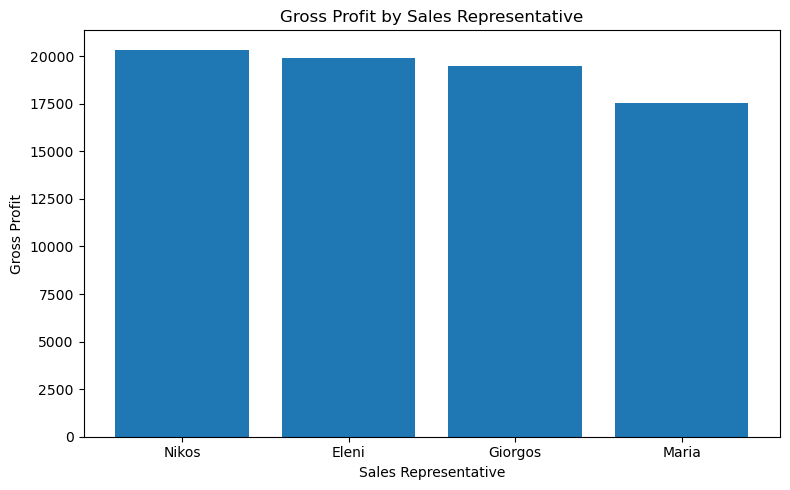

In [122]:
sales_rep_profit_sorted = sales_rep_summary.sort_values("gross_profit", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(sales_rep_profit_sorted["sales_rep"], sales_rep_profit_sorted["gross_profit"])
plt.title("Gross Profit by Sales Representative")
plt.xlabel("Sales Representative")
plt.ylabel("Gross Profit")
plt.tight_layout()


### 10.3 Discount band performance

In [245]:
conditions = [ 
    analysis_df["discount_pct"] == 0,
    analysis_df["discount_pct"] <= 0.03, 
    analysis_df["discount_pct"] <= 0.07,
    analysis_df["discount_pct"] <= 0.10
]

choices = [
    "no_discount",
    "low_discount",
    "medium_discount",
    "high_discount"
]

analysis_df["discount_band"] = np.select(
    conditions,
    choices,
    default="very_high_discount"
)
discount_order = [
    "no_discount",
    "low_discount",
    "medium_discount",
    "high_discount",
    "very_high_discount"
]

analysis_df["discount_band"] = pd.Categorical(
    analysis_df["discount_band"],
    categories=discount_order,
    ordered=True
)

In [247]:
discount_summary = analysis_df.groupby("discount_band", as_index=False).agg(
    total_orders=("order_id", "nunique"),
    total_qty=("quantity", "sum"),
    gross_revenue=("gross_revenue", "sum"),
    discount_amount=("discount_amount", "sum"),
    net_revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_discount_pct=("discount_pct", "mean"),
    avg_payment_days=("payment_days", "mean")
)

discount_summary["margin_pct"] = np.where(
    discount_summary["net_revenue"] != 0,
    discount_summary["gross_profit"] / discount_summary["net_revenue"],
    0
)

discount_summary["discount_pct_effective"] = np.where(
    discount_summary["gross_revenue"] != 0,
    discount_summary["discount_amount"] / discount_summary["gross_revenue"],
    0
)

discount_summary = discount_summary.sort_values("discount_band").reset_index(drop=True)

display(discount_summary)

C:\Users\papan\AppData\Local\Temp\ipykernel_8688\409804602.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_summary = analysis_df.groupby("discount_band", as_index=False).agg(


,discount_band,total_orders,total_qty,gross_revenue,discount_amount,net_revenue,gross_profit,avg_discount_pct,avg_payment_days,margin_pct,discount_pct_effective
0,no_discount,304,2966,45321.47,0.0000,44841.0800,17475.7300,0.000000,40.617128,0.389726,0.000000
1,low_discount,240,3267,51057.76,1311.5998,49301.0943,18682.2343,0.024551,41.490385,0.378942,0.025689
2,medium_discount,338,5745,89237.31,4801.8010,83449.2135,30234.7635,0.053376,39.645161,0.362313,0.053809
3,high_discount,148,2149,33308.70,2866.1746,30221.7861,10013.7561,0.086095,40.207101,0.331342,0.086049
4,very_high_discount,17,232,3383.04,399.0094,2939.4938,870.1438,0.118235,37.941176,0.296018,0.117944


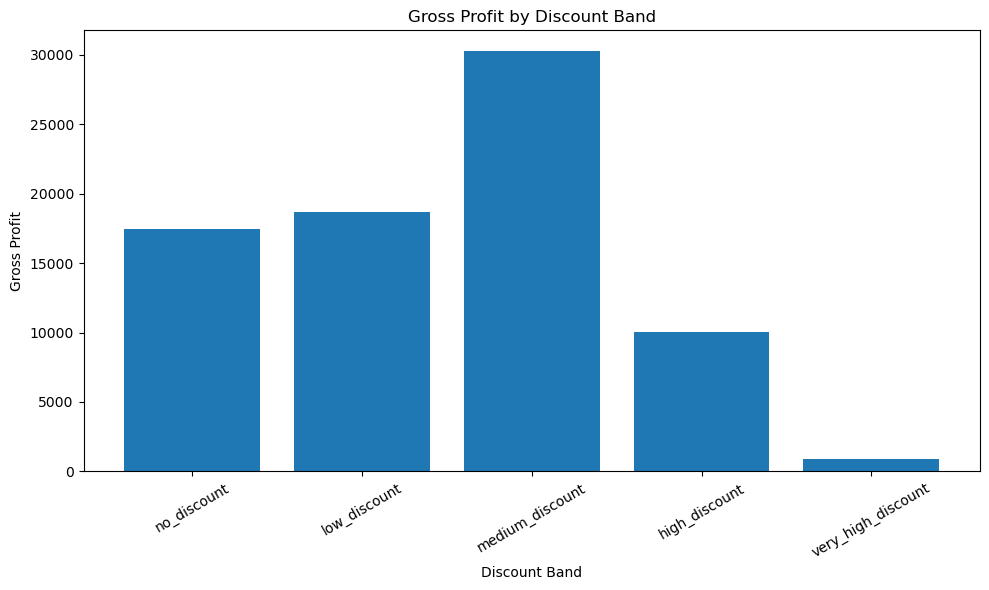

In [249]:
plt.figure(figsize=(10, 6))
plt.bar(discount_summary["discount_band"].astype(str), discount_summary["gross_profit"])
plt.title("Gross Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Gross Profit")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The discount band analysis shows that the medium discount range generates the highest gross profit. This does not prove that medium discounts directly cause higher profitability, but it suggests that the 3%–7% discount range is where the strongest profit contribution appears in this dataset.

Very high discounts contribute much less gross profit, while no-discount and low-discount orders remain important but do not produce the same total profit volume as the medium discount band. This indicates that moderate discounting may support sales volume without fully eroding profitability.

## 11. Export final datasets and figures

### 11.1 Create output folders

In [130]:
import os
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)


### 11.2 Export selected figures

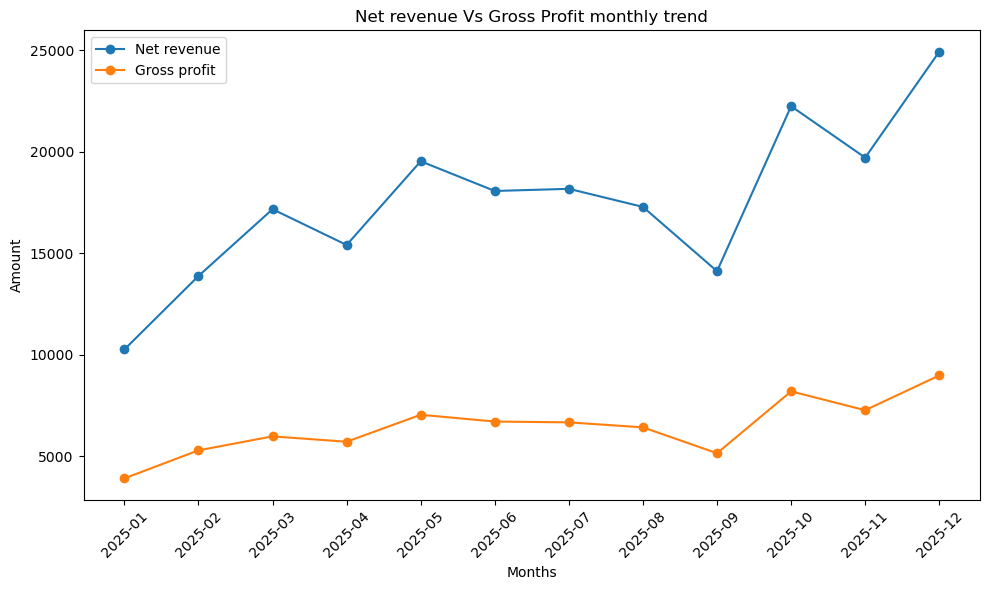

In [132]:
plt.figure(figsize=(10,6))

plt.plot(monthly_summary["order_month"], monthly_summary["net_revenue"], marker='o', label="Net revenue")
plt.plot(monthly_summary["order_month"], monthly_summary["gross_profit"], marker='o', label="Gross profit")

plt.title("Net revenue Vs Gross Profit monthly trend")
plt.xlabel("Months")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig("outputs/figures/monthly_revenue_profit_trend.png")

The chart shows how revenue and profit evolved during the year. The comparison helps identify months where sales volume increased without a proportional increase in profitability

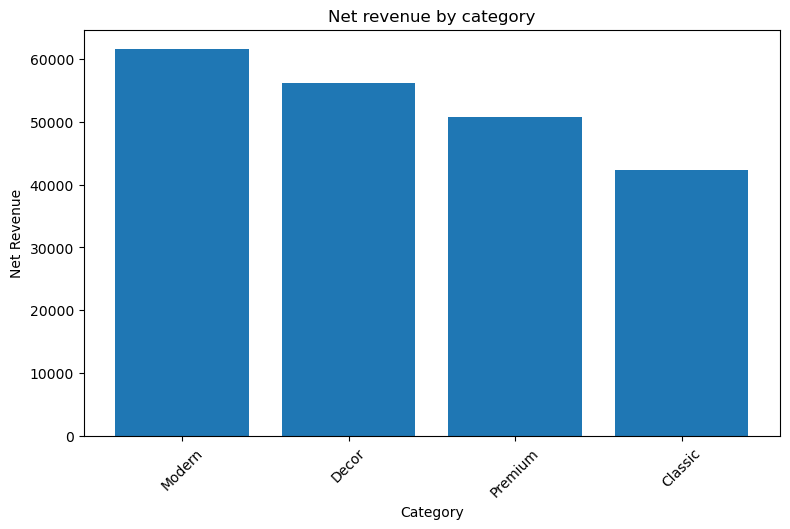

In [134]:
category_revenue_sorted = category_inventory_summary.sort_values("net_revenue", ascending=False)
plt.figure(figsize=(8,5))
plt.bar(category_revenue_sorted["category"], category_revenue_sorted["net_revenue"])
plt.title("Net revenue by category")
plt.xlabel("Category")
plt.ylabel("Net Revenue")
plt.tight_layout()
plt.xticks(rotation=45)

plt.savefig("outputs/figures/net_revenue_by_category.png", dpi=300)


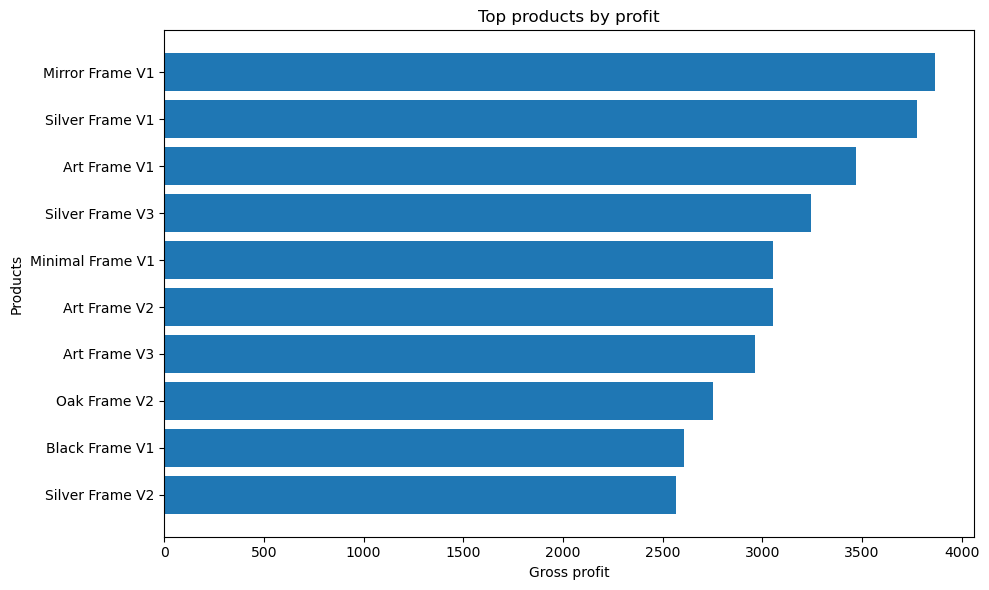

In [135]:
top_products_profit = product_summary.sort_values("gross_profit", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_products_profit["product_name"], top_products_profit["gross_profit"])
plt.title("Top products by profit")
plt.ylabel("Products")
plt.xlabel("Gross profit")
plt.tight_layout()
plt.gca().invert_yaxis()

plt.savefig("outputs/figures/top_products_by_profit.png", dpi=300)

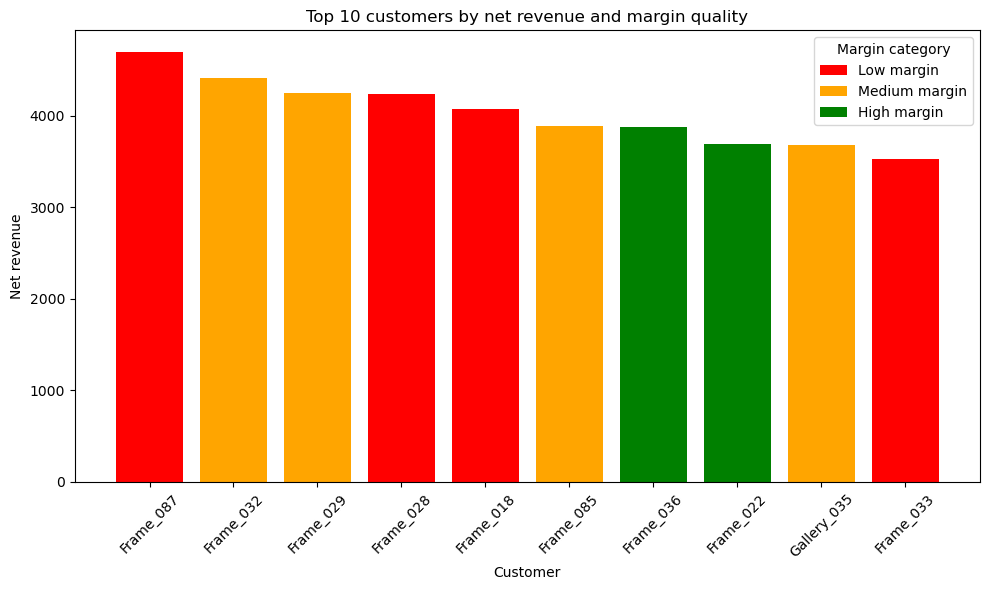

In [136]:
conditions=[
    customer_summary["margin_pct"] < customer_summary["margin_pct"].quantile(0.33),
    customer_summary["margin_pct"] < customer_summary["margin_pct"].quantile(0.66)
]

choices = [
    "low_margin",
    "medium_margin"
]

customer_summary["margin_category"] = np.select(
    conditions,
    choices,
    default="high_margin"
)

top_customers = customer_summary.sort_values(
    "net_revenue", ascending=False
).head(10)

color_map = {
    "high_margin": "green",
    "medium_margin": "orange",
    "low_margin": "red"
}

colors = top_customers["margin_category"].map(color_map)

plt.figure(figsize=(10, 6))
plt.bar(top_customers["customer_name"], top_customers["net_revenue"], color=colors)
plt.title("Top 10 customers by net revenue and margin quality")
plt.xlabel("Customer")
plt.ylabel("Net revenue")
plt.xticks(rotation=45)
plt.tight_layout()
from matplotlib.patches import Patch


plt.bar(
    top_customers["customer_name"],
    top_customers["net_revenue"],
    color=colors
)

legend_elements = [
    Patch(facecolor="red", label="Low margin"),
    Patch(facecolor="orange", label="Medium margin"),
    Patch(facecolor="green", label="High margin")
]

plt.legend(
    handles=legend_elements,
    title="Margin category"
)

plt.tight_layout()

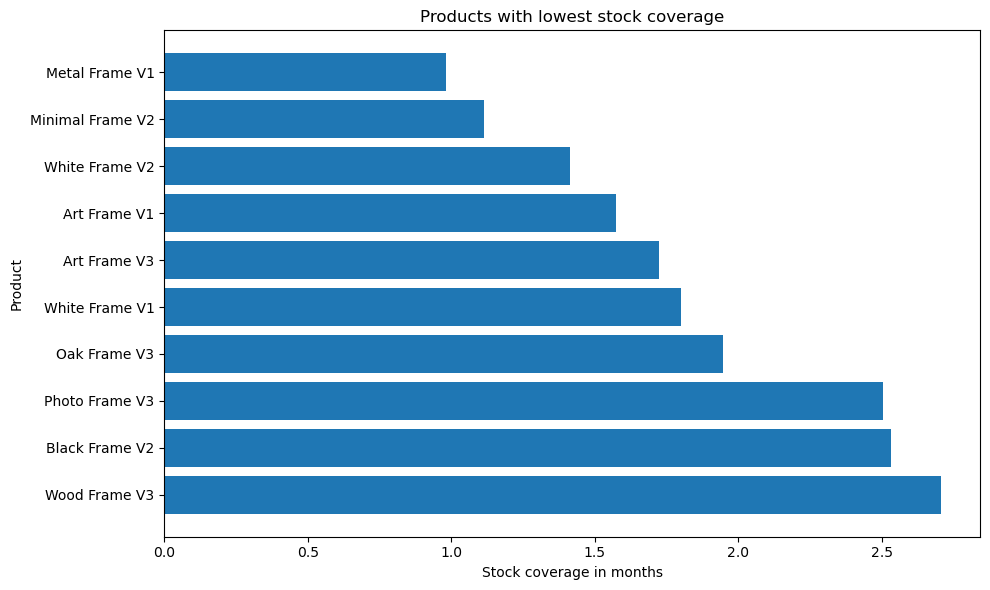

In [137]:
top_stock_pressure = (
    inventory_summary
    .sort_values("stock_coverage_months")
    .head(10)
)

plt.figure(figsize=(10,6))
plt.barh(
    top_stock_pressure["product_name"],
    top_stock_pressure["stock_coverage_months"]
)

plt.title("Products with lowest stock coverage")
plt.xlabel("Stock coverage in months")
plt.ylabel("Product")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("outputs/figures/products_lowest_stock_coverage.png", dpi=300)
plt.show()

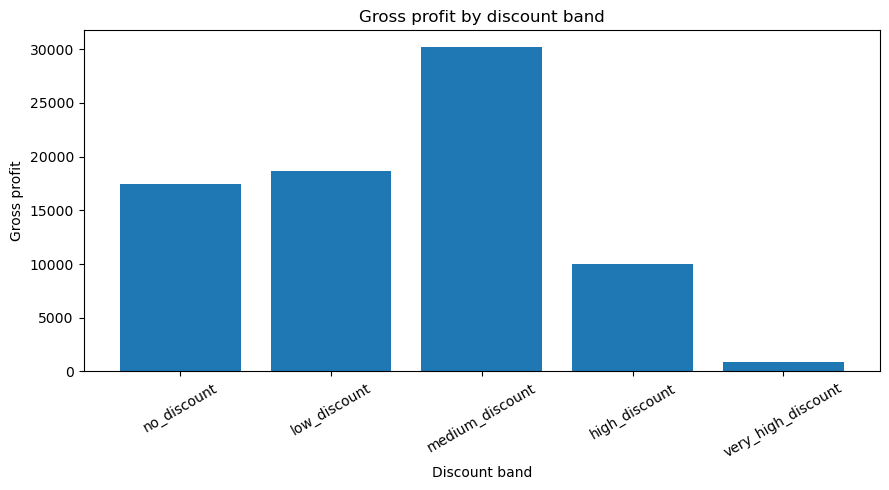

In [138]:
discount_order = [
    "no_discount",
    "low_discount",
    "medium_discount",
    "high_discount",
    "very_high_discount"
]

discount_summary["discount_band"] = pd.Categorical(
    discount_summary["discount_band"],
    categories=discount_order,
    ordered=True
)

discount_summary = discount_summary.sort_values("discount_band")

plt.figure(figsize=(9,5))
plt.bar(discount_summary["discount_band"], discount_summary["gross_profit"])
plt.title("Gross profit by discount band")
plt.xlabel("Discount band")
plt.ylabel("Gross profit")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("outputs/figures/gross_profit_by_discount_band.png", dpi=300)
plt.show()

### 11.3 Export summary tables

In [140]:
product_summary.to_csv("outputs/product_summary.csv", index=False)
customer_summary.to_csv("outputs/customer_summary.csv", index=False)
monthly_summary.to_csv("outputs/monthly_summary.csv", index=False)
inventory_summary.to_csv("outputs/inventory_summary.csv", index=False)
channel_summary.to_csv("outputs/channel_summary.csv", index=False)
sales_rep_summary.to_csv("outputs/sales_rep_summary.csv", index=False)
discount_summary.to_csv("outputs/discount_summary.csv", index=False)

immediate_reorder_list.to_csv("outputs/immediate_reorder_list.csv", index=False)
over_stock_list.to_csv("outputs/over_stock_list.csv", index=False)
strategic_products_list.to_csv("outputs/strategic_products_list.csv", index=False)

kpi_summary.to_csv("outputs/kpi_summary.csv", index=False)

# 12. Business insights and recommendations

This section summarises the main business findings from the sales, customer, product, inventory and discount analysis

### 12.1 Executive Summary

The analysis of completed orders shows annual net revenue of approximately €210.8K and gross profit of approximately €77.3K. The overall gross margin was around 36.7%, while the return rate remained low at approximately 1%, across 569 completed orders and 90 customers.

Across the analysis, revenue leaders were not always the strongest profit or margin performers. This pattern appeared at category, product and customer level, showing that commercial performance should be evaluated using a combination of revenue, gross profit, margin and operational indicators rather than net revenue alone.

Inventory analysis identified two different types of stock risk. Some profitable or fast-moving products had low stock coverage and should be monitored for replenishment risk, while some slow-moving products had high stock coverage and may require review for overstock risk.

Customer analysis showed that revenue alone is not sufficient to assess customer value. Some high-revenue customers had weaker margin quality, while other customers combined strong revenue with healthier profitability, lower returns or more controlled discount behaviour.

Discount analysis showed that very high discount levels can weaken margins and contribute limited gross profit. However, customer-level segmentation showed that several high-value customers received relatively higher discounts while still generating strong revenue and gross profit. This suggests that discounts are not automatically negative, but they should be monitored carefully to ensure they support profitable sales rather than simply increasing volume.

### 12.2 Product Insights

Product-level analysis showed that high revenue does not always translate into equally strong profitability. To evaluate this more clearly, products were compared using both revenue rank and profit rank.

Some products showed balanced performance. For example, Silver Frame V1 and Mirror Frame V1 appeared among the strongest products in both revenue and gross profit, suggesting that they combine sales volume with profitability.

Other products require closer review. White Frame V3 ranked very high in net revenue but had a relatively weak margin compared with other top revenue products. This suggests that its commercial performance should be interpreted carefully, as high revenue may be partly offset by lower profitability.

At category level, Modern generated the highest net revenue, while Decor achieved the highest gross profit and margin. This confirms that product and category performance should not be evaluated only by revenue, since the most commercially active category was not necessarily the most profitable one.

Finally, some high-profit products, such as Art Frame V1 and Art Frame V3, also appeared in reorder-related lists. These products are important from both a profitability and inventory perspective, because stock shortages could lead to lost profitable sales.

### 12.3 Customer Insights

Customer analysis shows that revenue and profitability should be evaluated together. Frame_087 generated the highest net revenue and ranked second in gross profit, making it one of the most important customers overall. However, its margin category was relatively weak compared with other top customers, suggesting that its profitability should be monitored rather than judged by revenue alone.

Frame_032 appears to be the strongest balanced customer, ranking second in net revenue and first in gross profit while maintaining a medium margin profile and a medium relative discount level. This suggests a strong combination of sales volume and profitability.

Some customers with slightly lower revenue, such as Frame_036 and Frame_022, showed stronger margin quality while still ranking highly in gross profit. These customers may be commercially attractive because they combine meaningful revenue with healthier profitability.

Overall, the customer analysis shows that high revenue customers are not necessarily problematic when margins are lower, especially if they still generate strong gross profit. A more useful customer view combines net revenue, gross profit, margin, discount behaviour and returns.


### 12.4 Time-Based Insights

Sales performance increased during the year, with a clear strengthening toward Q4. The final quarter was the strongest period in both net revenue and gross profit, suggesting higher commercial activity toward the end of the year.

December was the strongest month in net revenue, while October and November also showed strong performance. This indicates a possible year-end demand peak, although more years of data would be needed to confirm whether this is seasonality or a broader growth trend.

Gross profit followed the same general pattern as net revenue, showing that the increase in sales volume also translated into higher absolute profitability. Quarterly margins remained relatively stable, so the Q4 increase appears to be driven mainly by higher volume rather than a major change in margin rate.

The return rate declined toward the end of the year, which is a positive signal. This may reflect improved order quality, a better product/customer mix, or operational improvements, but further data would be needed to identify the exact cause.

Overall, the time-based analysis is useful for planning inventory ahead of peak periods, especially if the business expects similar year-end demand patterns in future years.

### 12.5 Inventory and Reorder Insights

Inventory analysis identified two different types of inventory risk. Based on the current stock snapshot, 7 products were flagged for urgent reorder and 4 additional products were placed on a watchlist. Together, these 11 products represent around 31% of the product catalogue, meaning that nearly one third of the assortment currently requires replenishment monitoring.

Metal Frame V1 and Minimal Frame V2 require immediate attention because they are fast-moving products with stockout risk. Some urgent reorder products are also important from a profitability perspective. Art Frame V1 and Art Frame V3 have limited stock coverage while generating strong gross profit, so stock shortages in these products could lead to lost profitable sales.

At the other end of the inventory spectrum, 7 slow-moving products were identified with high stock coverage, indicating possible overstock risk. This represents around 19% of the product catalogue and suggests that part of the assortment may be tying up stock without moving quickly enough.

### 12.6 Channel, Sales Rep and Discount Insights

Wholesale was the dominant sales channel, generating the highest net revenue and gross profit by a wide margin. Since margin differences between channels were relatively small, Wholesale’s advantage appears to come mainly from sales scale rather than a substantially higher margin rate. Its performance was not driven by materially worse margins, heavier discounts or slower payments, although returns and customer mix should still be monitored.

Sales representatives showed relatively similar margins, although differences appeared in revenue, gross profit, discount behaviour and return rates. This suggests that sales performance should be reviewed using both volume and quality metrics, rather than revenue alone.

Discount analysis showed that margin tends to decline as discount levels increase, which is expected. However, the gross profit view gives a more useful business interpretation: the 3%–7% discount range appears to be the strongest commercial zone in this dataset, generating the highest total gross profit. This does not prove that this discount range directly causes higher profitability, but it suggests that moderate discounts may support sales volume without fully eroding profit contribution. No-discount and low-discount sales preserve stronger margins, while very high discounts contribute less total gross profit.

At customer level, this finding should be interpreted selectively rather than mechanically. Several high-value customers received discounts within or close to the moderate discount range, while still generating strong revenue and gross profit. This suggests that discounts are not automatically negative when they support profitable customer relationships. However, very high discounts should still be used carefully, mainly for cases such as overstock reduction, strategic customer retention or clearance of slow-moving inventory.

### 12.7 Business recommendations

#### Prioritise products using revenue, profit and inventory metrics

Product decisions should not be based only on net revenue. Some products generate strong sales but weaker profitability, while others combine strong revenue, gross profit and healthier margins. Product reviews should therefore include revenue rank, profit rank, margin percentage and inventory status together.

#### Strengthen inventory monitoring and replenishment planning

The analysis flagged 7 products for urgent reorder and 4 additional products for watchlist monitoring, representing around 31% of the product catalogue. Fast-moving and high-profit products should be prioritised because stockouts could lead to lost revenue and lost profitable sales. Slow-moving products with high stock coverage should also be reviewed to reduce overstock risk and avoid tying up working capital.

#### Use customer segmentation and discounts selectively

Customer value should be assessed using revenue, gross profit, margin, discount behaviour and returns together. High-revenue customers are not always the most profitable, so customer reviews should distinguish between high-volume customers, high-margin customers and accounts requiring closer commercial monitoring. Discounts should be applied selectively, with the 3%–7% range appearing to be the strongest gross profit zone in this dataset, while very high discounts should be reserved for clear business purposes.

#### Explore supplier and purchasing cost optimisation

Because discounts reduce the gap between selling price and unit cost, the business should explore supplier negotiations, larger purchase quantities or alternative suppliers as a next step. Lower unit costs would improve gross margins and create more flexibility for controlled discounts. This recommendation should be validated with supplier prices, freight costs, lead times and minimum order quantities.

#### Create a recurring monthly reporting process

The summary tables and charts created in this project should be updated monthly to support purchasing, inventory and sales decisions. A regular report should track KPIs, top products, customer quality, urgent reorder items, overstock risk, discount performance and monthly trends.


### 12.8 Limitations

- The dataset is synthetic and simplified compared with a real business database, so the results should be interpreted as a portfolio analysis rather than a real company audit.

- The analysis covers one year of completed sales data. This is enough to identify monthly and quarterly patterns, but not enough to confirm long-term seasonality or multi-year growth trends.

- Inventory analysis is based on a current stock snapshot. The dataset does not include historical stock movements, supplier lead times or replenishment dates, so reorder and overstock findings should be interpreted as point-in-time signals.

- Gross profit is calculated from sales price, discounts and unit cost, but the analysis does not include operating costs such as delivery costs, warehouse handling, labour time, marketing costs or customer servicing effort.

- Customer and discount analysis is descriptive. The results show patterns and associations, but they do not prove causal effects between discounts, sales volume and profitability.

- Supplier-side analysis is limited because the dataset does not include supplier options, purchase volume discounts, lead times or quality differences. Therefore, supplier cost optimisation is recommended as a next step rather than directly measured in this project.

### 12.9 Next steps

Future improvements could include:

- Extend the SQL analysis and compare key outputs against the pandas workflow to ensure consistency across tools.
- Build an interactive Power BI dashboard for sales, customer, product and inventory monitoring.
- Create a monthly reporting process that updates KPIs, product rankings, customer segments, reorder risk and overstock risk.
- Apply ABC analysis to prioritise inventory based on revenue, gross profit and movement speed.
- Add supplier lead times, purchasing costs, freight costs and minimum order quantities to improve reorder planning.
- Develop demand forecasting for key fast-moving and high-profit products.
- Expand the customer analysis with cohort or retention analysis if multi-year customer data becomes available.
- Include operational cost data, such as delivery, warehouse handling and order processing effort, to estimate customer and product profitability more accurately.